In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def extract_data(filedir):
    files = os.listdir(filedir)
    df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
    df_list = [df.drop(0) for df in df_list]
    df_list = [df.drop(df.columns[list(range(-1, -9, -1))], axis=1) for df in df_list]
    data = pd.concat(df_list, ignore_index=True)    
    return data


dir1 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data1_83"
dir2 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data2_e8"


data1 = extract_data(dir1)
data2 = extract_data(dir2)

print(data1.shape)
print(data2.shape)

def time_transform(arr):

    arr = np.array([t.replace(":", ".").split(".") for t in arr], dtype=float)
    secs = arr[:,0]*3600 + arr[:,1]*60 + arr[:,2] + arr[:,3]/1000
    return secs

time_onchip1 = time_transform([x.split(" ", 2)[2] for x in data1[2]])
time_onchip2 = time_transform([x.split(" ", 2)[2] for x in data2[2]])


time_sys1 = time_transform(data1[0])
time_sys2 = time_transform(data2[0])

#测试掉帧
t1 = time_onchip1
t2 = time_onchip2


def frameloss_test(t):
    fl_count = 0
    lostframes = 0 
    for i in range(1, len(t)):
        if float(t[i]) - float(t[i-1]) >= 0.02:
            fl_count += 1
            lostframes += int((t[i] - t[i-1]) / 0.01) - 1
            #print(f"Frame loss between {i-1} and {i}: {t[i] - t[i-1]:.3f} seconds")        
    print(f"frame loss count: {fl_count}")
    print(f"total lost frames: {lostframes}")

frameloss_test(t1)
frameloss_test(t2)



C:\Users\Shubai\AppData\Local\Temp\ipykernel_23692\800337783.py:11: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_23692\800337783.py:11: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_23692\800337783.py:11: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shub

(461628, 15)
(460404, 15)
frame loss count: 223
total lost frames: 93373806
frame loss count: 335
total lost frames: 2699


In [18]:

import numpy as np
from scipy.interpolate import PchipInterpolator
def align_imu(data):
    """
    data: ndarray, 列0=系统时间, 列2=片上时间, 列3:15=信号(12通道)
    返回: t_new, out, fs, drift
    """
    # 强制数值化，避免字符串输入
    ts = data[:, 0]
    ts = np.array([t.replace(":", ".").split(".") for t in ts], dtype=float)
    ts = ts[:,0]*3600 + ts[:,1]*60 + ts[:,2] + ts[:,3]/1000
    
    tc = data[:, 2]
    tc = [x.split(" ", 2)[2] for x in tc]
    tc = np.array([t.replace(":", ".").split(".") for t in tc], dtype=float)
    tc = tc[:,0]*3600 + tc[:,1]*60 + tc[:,2] + tc[:,3]/1000

    sig = data[:, 3:15].astype(np.float64)
    
    # 1. 清洗片上时间异常
    dt = np.diff(tc)
    ok = np.concatenate(([True], (dt > 0) & (dt < 0.5)))
    ts, tc, sig = ts[ok], tc[ok], sig[ok]
    
    # 2. 晶振频偏拟合
    k, b = np.polyfit(ts, tc, 1)
    fs = 100.0 * k
    drift = (1.0 - k) * 100
    
    # 3. 反解平滑真实时间轴
    t_est = (tc - b) / k
    
    # 4. 等间隔目标轴
    dt = 1.0 / fs
    t_new = np.arange(t_est[0], t_est[-1] + dt/2, dt)
    
    out = np.zeros((len(t_new), sig.shape[1]))
    for i in range(sig.shape[1]):
        pchip = PchipInterpolator(t_est, sig[:, i])
        out[:, i] = pchip(t_new)
    
    return t_new, out, sig, fs, drift, t_est

t_new1, sig1, sig_ori1, fs1, drift1, t_est1 = align_imu(data1.values)
t_new2, sig2, sig_ori2, fs2, drift2, t_est2 = align_imu(data2.values)
t_new1 = t_new1-t_new1[0]
t_new2 = t_new2-t_new2[0]



In [19]:

ta = t_new1 - 6.6
tb = t_new2 - 6.6

ta_p = ta[ta >= 0]
imu_a = sig1[-len(ta_p):]
tb_p = tb[tb >= 0]
imu_b = sig2[-len(tb_p):]

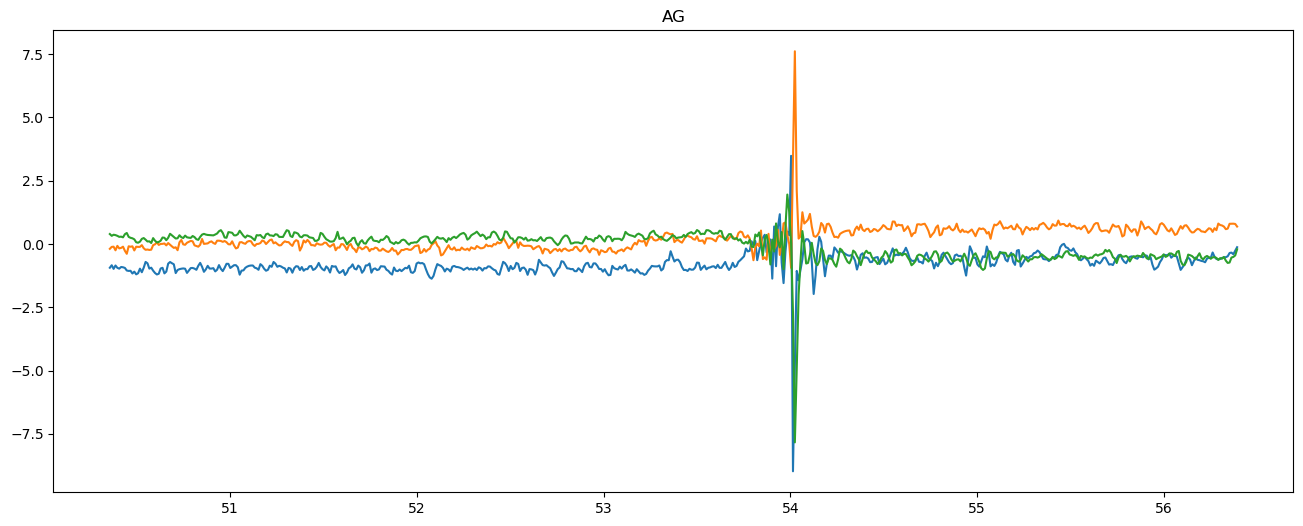

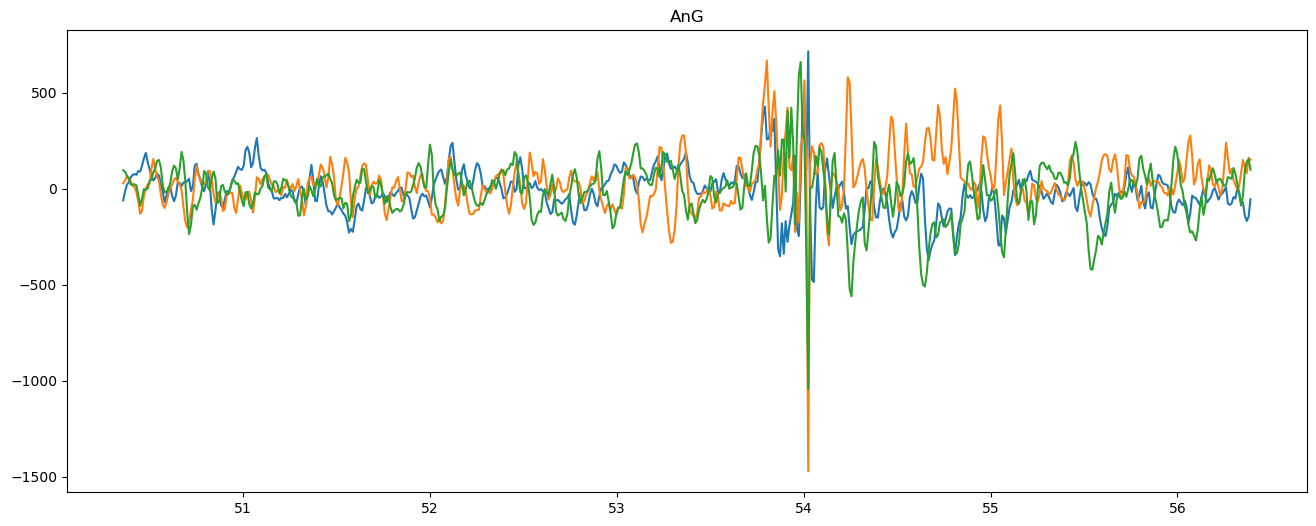

In [5]:
#绘图检查时间和视频对应关系
%matplotlib inline
import matplotlib.pyplot as plt
s = 50
e = 56



start = s*100
end = e*100
figsize = (16, 6)

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(t_new1[start:end], sig1[start:end,0])
ax.plot(t_new1[start:end], sig1[start:end,1])
ax.plot(t_new1[start:end], sig1[start:end,2])
ax.xaxis.set_major_locator(plt.MultipleLocator(1))  # 间隔改为1
plt.title("AG")
plt.show()

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(t_new2[start:end], sig1[start:end,3])
ax.plot(t_new2[start:end], sig1[start:end,4])
ax.plot(t_new2[start:end], sig1[start:end,5])
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
plt.title("AnG")
plt.show()

In [20]:
#数据预处理
import numpy as np

def preprocess_segment(data):
    """
    单段 9 轴 IMU 预处理。
    
    输入
    ----
    data : np.ndarray, shape (n, 9)
        列顺序: [ax, ay, az, wx, wy, wz, roll, pitch, yaw]
        单位: 加速度(g), 角速度(°/s), 角度(°)
        
    输出
    ----
    np.ndarray, shape (n, 12)
        列顺序: [aGx, aGy, aGz, anGx, anGy, anGz, wx, wy, wz, roll, pitch, yaw]
    """
    a_raw = data[:, 0:3].astype(float)
    w_raw = data[:, 3:6].astype(float)
    r_deg = data[:, 6:9].astype(float)

    # 1. 陀螺仪零偏：整段中位数（角速度理论上均值为0）
    w = w_raw - np.median(w_raw, axis=0)

    # 2. 欧拉角 -> 旋转矩阵 R (head -> Earth, ZYX 内旋: yaw→pitch→roll)
    #    如果传感器角度顺序不同，请修改此矩阵
    r = np.radians(r_deg)
    cr, sr = np.cos(r[:, 0]), np.sin(r[:, 0])   # roll
    cp, sp = np.cos(r[:, 1]), np.sin(r[:, 1])   # pitch
    cy, sy = np.cos(r[:, 2]), np.sin(r[:, 2])   # yaw

    R = np.zeros((len(data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr
    R[:, 2, 2] = cp * cr

    # 3. 头部参考系中的重力分量 aG = R^T · [0, 0, 1]
    aG = np.einsum('nij,j->ni', R.transpose(0, 2, 1), np.array([0., 0., 1.]))

    # 验证：aG 模长必须恒为 1.0。若报错，说明角度顺序/定义与代码不符
    assert np.allclose(np.linalg.norm(aG, axis=1), 1.0, atol=0.05), \
        "aG 模长不恒为 1g，请检查 roll/pitch/yaw 是否为 ZYX 内旋顺序"

    # 4. 加速度零偏：利用 anG 应近似零均值的特性
    #    a_raw = aG + anG_true + bias  =>  a_raw - aG = anG_true + bias
    #    取中位数即可分离出 bias（假设真实运动加速度 anG_true 的中位数为0）
    acc_bias = np.median(a_raw - aG, axis=0)
    a = a_raw - acc_bias

    # 5. 非重力加速度
    anG = a - aG
    list_new = np.concatenate([aG, anG, w, r_deg, a], axis=1)

    return list_new

imu_preprocessed1 = preprocess_segment(imu_a)
imu_preprocessed2 = preprocess_segment(imu_b)



In [21]:
#将数据切割为30s的片段

def segmentation(t, imu):
    data_seg = []
    t_seg = []
    seg_len = 60
    edges = np.arange(t[0] // seg_len * seg_len, t[-1] + seg_len, seg_len)
    ix = np.searchsorted(t, edges)

    for s, e in zip(ix, ix[1:]):
        if e <= s: continue
        ti, imui = t[s:e], imu[s:e]
        data_seg.append(imui)
        t_seg.append(ti)
    return data_seg, t_seg


seg_data1, seg_t1 = segmentation(ta_p, imu_preprocessed1)
seg_data2, seg_t2 = segmentation(ta_p, imu_preprocessed2)

In [22]:
import numpy as np
import ruptures as rpt

def compute_global_gamma(seg_list):
    """
    从多个片段（如前三段）中计算全局稳定的 gamma。
    seg_list: list of np.ndarray, each (n, 12)
    """
    # 合并所有片段的 aG + ω
    all_signal = []
    for seg in seg_list:
        signal_cpd = np.concatenate([seg[:, 12:15], seg[:, 6:9]], axis=1)
        all_signal.append(signal_cpd)
    
    full_signal = np.vstack(all_signal)
    
    # z-score
    mu = np.mean(full_signal, axis=0)
    sigma = np.std(full_signal, axis=0) + 1e-12
    signal_z = (full_signal - mu) / sigma
    
    # 基于总方差的稳定 gamma
    total_var = np.sum(np.var(signal_z, axis=0))
    gamma = 1.0 / total_var if total_var > 0 else 1.0
    
    return gamma

def search_penalty_for_target_duration(data, gamma, sr=100.0, min_size=10, target_ms=377.0):
    """
    搜索 penalty，使得中位段长接近目标时长（毫秒）。
    返回最优 penalty 和对应的中位段长（毫秒）。
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return 0.1, n_samples / sr * 1000.0
    
    # 准备 CPD 输入信号
    signal_cpd = np.concatenate([data[:, 12:15], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    # 目标段长（样本数）
    target_len = target_ms / 1000.0 * sr
    
    # 在 log 空间搜索 penalty
    penalties = np.logspace(-1, 2, 30)  # 0.1 ~ 100
    best_pen = penalties[0]
    best_err = np.inf
    best_med_ms = None
    
    for pen in penalties:
        algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
        algo.fit(signal_z)
        bkps = algo.predict(pen=pen)
        
        # 计算各段长度
        seg_lengths = [bkps[i] - bkps[i-1] for i in range(1, len(bkps))]
        if len(seg_lengths) == 0:
            continue
        
        med_len = np.median(seg_lengths)
        med_ms = med_len / sr * 1000.0
        err = abs(med_ms - target_ms)
        
        if err < best_err:
            best_err = err
            best_pen = pen
            best_med_ms = med_ms
    
    return best_pen, best_med_ms


def dissect_imu_single(data, gamma, penalty, sr=100.0, min_size=10):
    """
    单段 CPD，使用给定的全局 gamma 和 penalty。
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return [data]
    
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    algo = rpt.KernelCPD(kernel="rbf", min_size=min_size)
    algo.fit(signal_z)
    bkps = algo.predict(pen=penalty)
    
    segments = []
    start = 0
    for end in bkps:
        if end - start >= min_size:
            segments.append(data[start:end, :])
        start = end
    
    return segments



global_gamma1 = compute_global_gamma([seg_data1[1], seg_data1[2], seg_data1[3]])
print(f"Global gamma1 = {global_gamma1:.4f}")



penalty_377, med_ms = search_penalty_for_target_duration(
    seg_data1[1], 
    gamma=global_gamma1, 
    sr= fs1, 
    min_size=10, 
    target_ms=377.0
)
print(f"搜索到的 penalty = {penalty_377:.2f}, 中位段长 = {med_ms:.1f} ms")

segnum = 19

data1_CPDsegments = []
for index in range(2, segnum):
    segs = dissect_imu_single(seg_data1[index], gamma=global_gamma1, penalty=2.6, sr=fs1, min_size=10)
    data1_CPDsegments.extend(segs)
    print(f"Segment {index}: {len(segs)} sub-segs")

all_lengths = [len(seg) / 100.0 * 1000.0 for seg in data1_CPDsegments]
print(f"全局中位段长: {np.median(all_lengths):.1f} ms")

print(f"总片段数: {len(data1_CPDsegments)}")
y = [len(s) for s in data1_CPDsegments]
print(sum(y))
t1_CPDsegments = ta_p[len(seg_t1[0])+len(seg_t1[1]):len(seg_t1[0])+len(seg_t1[1]) +sum(y)]
#t1_CPDsegments = ta_p[0:sum(y)]


Global gamma1 = 0.1667
搜索到的 penalty = 3.56, 中位段长 = 322.3 ms
Segment 2: 209 sub-segs
Segment 3: 213 sub-segs
Segment 4: 216 sub-segs
Segment 5: 227 sub-segs
Segment 6: 214 sub-segs
Segment 7: 213 sub-segs
Segment 8: 203 sub-segs
Segment 9: 226 sub-segs
Segment 10: 249 sub-segs
Segment 11: 248 sub-segs
Segment 12: 188 sub-segs
Segment 13: 201 sub-segs
Segment 14: 198 sub-segs
Segment 15: 220 sub-segs
Segment 16: 204 sub-segs
Segment 17: 199 sub-segs
Segment 18: 181 sub-segs
全局中位段长: 200.0 ms
总片段数: 3609
101274


In [23]:

global_gamma2 = compute_global_gamma([seg_data2[1], seg_data2[2], seg_data2[3]])
print(f"Global gamma2 = {global_gamma2:.4f}")

data2_CPDsegments = []
for index in range(2, segnum):
    segs = dissect_imu_single(seg_data2[index], gamma=global_gamma2, penalty=2.6, sr=fs1, min_size=10)
    data2_CPDsegments.extend(segs)
    print(f"Segment {index}: {len(segs)} sub-segs")

all_lengths = [len(seg) / 100.0 * 1000.0 for seg in data2_CPDsegments]
print(f"全局中位段长: {np.median(all_lengths):.1f} ms")

print(f"总片段数: {len(data2_CPDsegments)}")
y2 = [len(s) for s in data2_CPDsegments]
print(sum(y2))
t2_CPDsegments = tb_p[len(seg_t2[0])+len(seg_t2[1]):len(seg_t2[0])+len(seg_t2[1]) +sum(y2)]

Global gamma2 = 0.1667
Segment 2: 233 sub-segs
Segment 3: 259 sub-segs
Segment 4: 243 sub-segs
Segment 5: 238 sub-segs
Segment 6: 213 sub-segs
Segment 7: 205 sub-segs
Segment 8: 228 sub-segs
Segment 9: 195 sub-segs
Segment 10: 200 sub-segs
Segment 11: 207 sub-segs
Segment 12: 178 sub-segs
Segment 13: 182 sub-segs
Segment 14: 166 sub-segs
Segment 15: 169 sub-segs
Segment 16: 149 sub-segs
Segment 17: 141 sub-segs
Segment 18: 166 sub-segs
全局中位段长: 200.0 ms
总片段数: 3372
101274


In [9]:
#裁剪视频以确认时间对齐
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

def extract_clip(video_path, data, timestamps, t_start, t_end, output_dir, fs=100.0):
    """
    从视频中截取指定时间范围的片段，并生成对应 IMU 数据图。
    
    参数
    ----
    video_path : str
    data : np.ndarray, shape (n, 12)
        [aGx,aGy,aGz, anGx,anGy,anGz, wx,wy,wz, roll,pitch,yaw]
    timestamps : np.ndarray, shape (n,)
    t_start, t_end : float
        截取起止时间（单位与 timestamps 一致）
    output_dir : str
    fs : float
        采样率，用于计算时长
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. 截取 IMU 数据
    times = np.asarray(timestamps).flatten()
    idx0 = np.searchsorted(times, t_start)
    idx1 = np.searchsorted(times, t_end)
    idx0 = max(0, idx0)
    idx1 = min(len(times), idx1)
    
    seg_data = data[idx0:idx1]
    seg_times = times[idx0:idx1]
    seg_duration = (idx1 - idx0) / fs
    
    # 2. 截取视频
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    f0 = max(0, int(np.floor(t_start * fps)))
    f1 = min(total_frames, int(np.ceil(t_end * fps)) + 1)
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
    ret, frame = cap.read()
    if not ret:
        cap.release()
        return
    
    h, w = frame.shape[:2]
    out_video = os.path.join(output_dir, f"clip_{t_start:.1f}s_{t_end:.1f}s.mp4")
    writer = cv2.VideoWriter(out_video, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    writer.write(frame)
    
    for _ in range(f1 - f0 - 1):
        ret, frame = cap.read()
        if not ret:
            break
        writer.write(frame)
    
    writer.release()
    cap.release()
    
    # 3. 绘制数据图
    t_rel = np.arange(len(seg_data)) / fs
    fig_width = max(5.0, seg_duration * 3.0)
    fig, axes = plt.subplots(2, 1, figsize=(fig_width, 5.5), sharex=True)
    
    colors_aG = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for ch in range(3):
        axes[0].plot(t_rel, seg_data[:, ch], color=colors_aG[ch], lw=1.2, label=f'aG_{ch}')
    axes[0].set_ylabel('aG (g)')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    colors_w = ['#d62728', '#9467bd', '#8c564b']
    for ch in range(3):
        axes[1].plot(t_rel, seg_data[:, ch + 6], color=colors_w[ch], lw=1.2, label=f'ω_{ch}')
    axes[1].set_ylabel('ω (°/s)')
    axes[1].set_xlabel('Time (s)')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, seg_duration)
    
    plt.tight_layout()
    out_plot = os.path.join(output_dir, f"clip_{t_start:.1f}s_{t_end:.1f}s_signal.png")
    plt.savefig(out_plot, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"Video: {out_video}")
    print(f"Plot:  {out_plot}")
    print(f"Duration: {seg_duration:.2f}s, Frames: {f1-f0}, Samples: {idx1-idx0}")


# ========== 使用示例 ==========
extract_clip(
    video_path="F:/IMU_computational_ethology/Data/2mouse/data2_batch.mp4",
    data= imu_a,
    timestamps= ta_p,
    
    t_start=47.4,
    t_end=48,
    output_dir="F:/IMU_computational_ethology/Data/2mouse",
    fs=100.0
)

Video: F:/IMU_computational_ethology/Data/2mouse\clip_47.4s_48.0s.mp4
Plot:  F:/IMU_computational_ethology/Data/2mouse\clip_47.4s_48.0s_signal.png
Duration: 0.60s, Frames: 20, Samples: 60


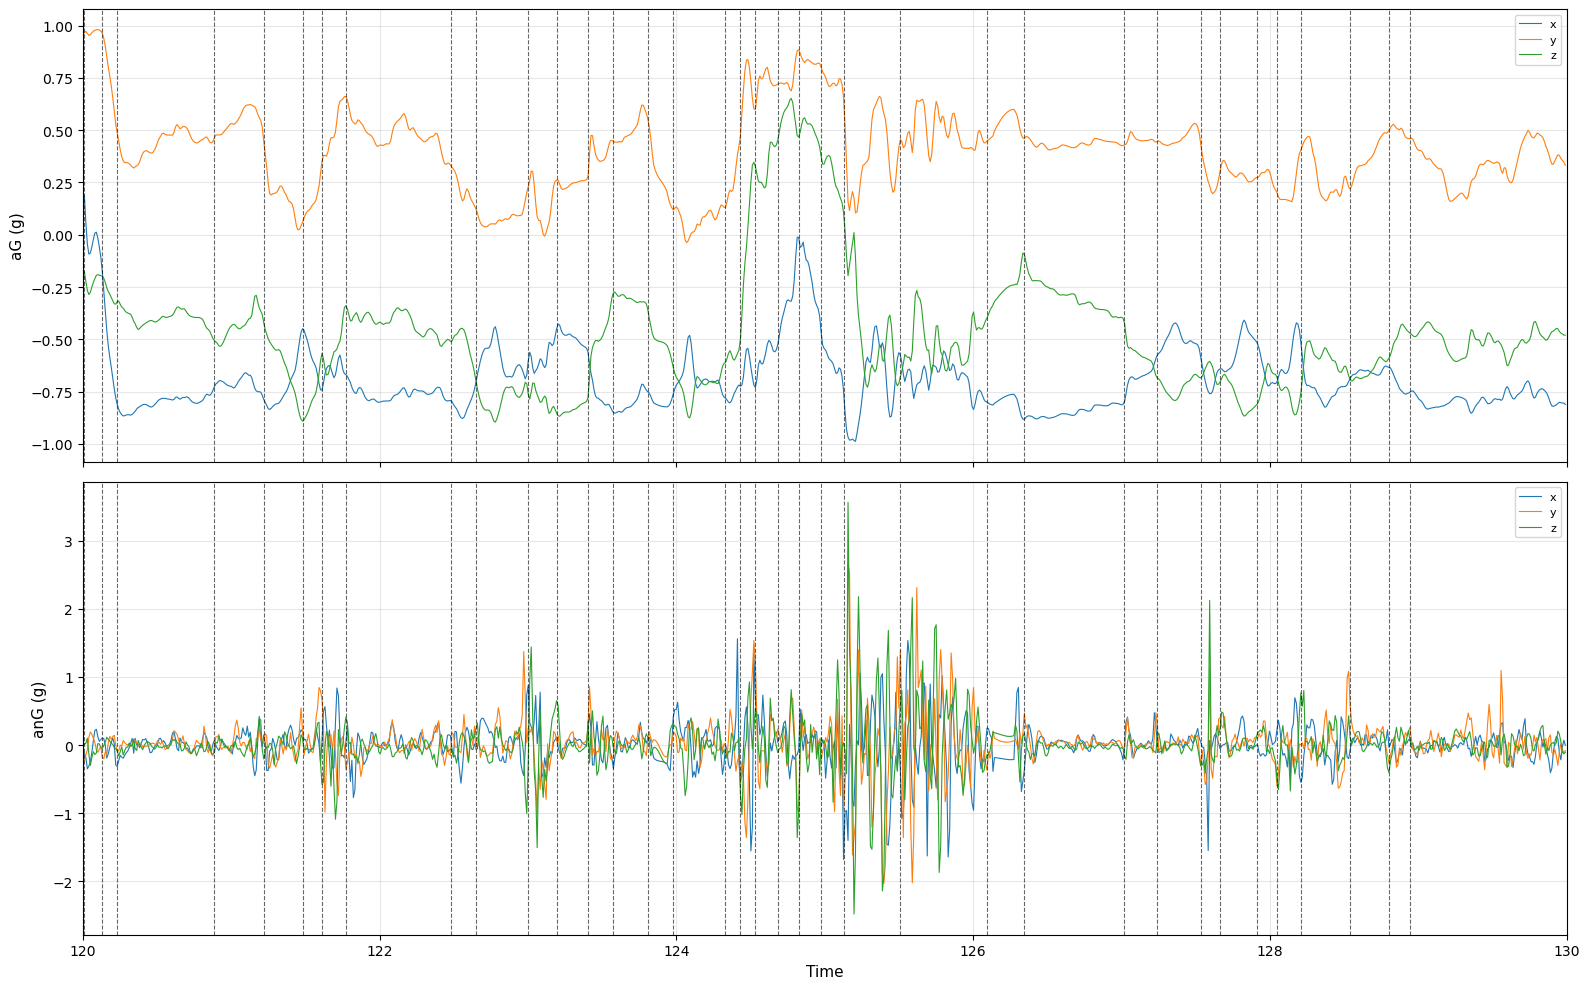

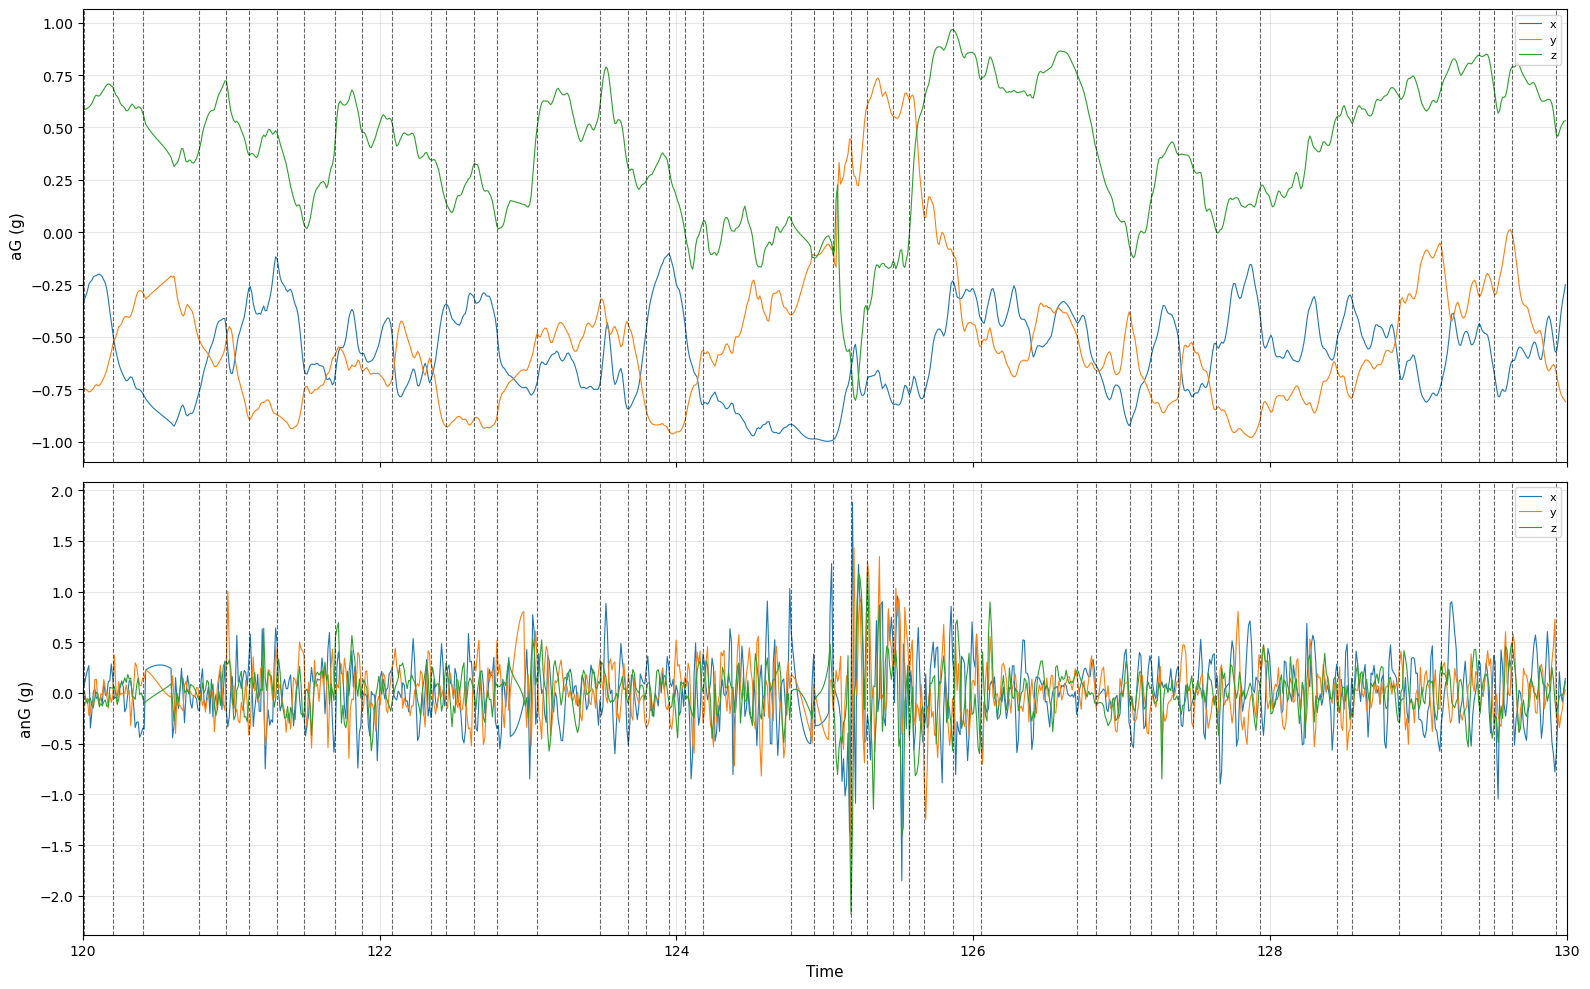

In [61]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def plot_segments_with_labels(data_segments, timestamps,  
                               t_start=None, t_end=None, 
                               figsize=(16, 10)):
    """
    绘制分段 IMU 数据，按时间戳截断，虚线分隔片段，并标注类别。
    
    参数
    ----
    data_segments : list of np.ndarray
        每段 (m, 12)，列顺序: [aGx,aGy,aGz, anGx,anGy,anGz, wx,wy,wz, roll,pitch,yaw]
    timestamps : np.ndarray
        连续时间戳，长度等于所有段样本数之和
    labels : np.ndarray or list
        每段对应的类标签
    t_start, t_end : float or None
        绘制的时间范围（单位与 timestamps 一致）。None 表示全部绘制。
    figsize : tuple
        图像尺寸
    """
    # 1. 拼接完整数据
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    
    # 2. 时间截断
    if t_start is None:
        t_start = full_times[0]
    if t_end is None:
        t_end = full_times[-1]
    
    idx0 = np.searchsorted(full_times, t_start)
    idx1 = np.searchsorted(full_times, t_end)
    idx0 = max(0, idx0)
    idx1 = min(len(full_times), idx1)
    
    times = full_times[idx0:idx1]
    data = full_data[idx0:idx1, :]
    
    # 3. 计算每段在全局时间中的起止（只保留与视图有交集的）
    seg_starts = []
    seg_ends = []
    seg_labels_view = []
    
    cumsum = 0
    for i, seg in enumerate(data_segments):
        seg_len = len(seg)
        seg_t0 = full_times[cumsum]
        seg_t1 = full_times[cumsum + seg_len - 1] if seg_len > 1 else full_times[cumsum]
        
        if seg_t1 >= t_start and seg_t0 <= t_end:
            seg_starts.append(seg_t0)
            seg_ends.append(seg_t1)
        
        cumsum += seg_len
    
    # 4. 绘图
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    groups = [
        (data[:, 0:3], 'aG (g)', ['x', 'y', 'z']),
        (data[:, 3:6], 'anG (g)', ['x', 'y', 'z']),
        (data[:, 6:9], 'ω (°/s)', ['x', 'y', 'z'])
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for ax, (d, title, ch_names) in zip(axes, groups):
        # 画三通道曲线
        for ch in range(3):
            ax.plot(times, d[:, ch], color=colors[ch], lw=0.8, label=ch_names[ch])
        
        # 画虚线边界
        for t_b in seg_starts:
            if t_start <= t_b <= t_end:
                ax.axvline(t_b, color='black', linestyle='--', lw=0.8, alpha=0.6)
        
        # 标注类别：在片段中点上方，黄底黑字
        
        ax.set_ylabel(title, fontsize=11)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(t_start, t_end)
    
    axes[-1].set_xlabel('Time', fontsize=11)
    plt.tight_layout()
    plt.show()


# ========== 使用示例 ==========
plot_segments_with_labels(
    data_segments= data1_CPDsegments,      # list of (m, 12)
    timestamps=t1_CPDsegments,         # (n_total,)
    t_start=120,                       # 从第 0 秒开始
    t_end=130,                       # 画前 30 秒
    figsize=(16, 10)
)


plot_segments_with_labels(
    data_segments= data2_CPDsegments,      # list of (m, 12)
    timestamps=t2_CPDsegments,         # (n_total,)
    t_start=120,                       # 从第 0 秒开始
    t_end=130,                       # 画前 30 秒
    figsize=(16, 10)
)

In [24]:
#提取240维特征
import numpy as np
from numpy.linalg import norm

def extract_features(seg_data, fs=100):
    channels = []
    feats = []
    aG = seg_data[:, 0:3].astype(float)
    anG = seg_data[:,3:6].astype(float)
    w = seg_data[:, 6:9].astype(float)
    angles = seg_data[:, 9:12].astype(float)
    
    for ch in range(9):
        x = seg_data[:, ch]
        channels +=  [x]
    
    for ch in range(9):
        x = seg_data[:, ch]
        gradx = np.gradient(x, 1/fs)
        channels += [gradx]
    
    norm_w = np.linalg.norm(seg_data[:, 6:9], axis=1)
    norm_ang = np.linalg.norm(seg_data[:, 3:6], axis=1)
    channels += [norm_w, norm_ang]
    #构建20类数据
    
    for ch in channels:
        mean = np.mean(ch)
        std = np.std(ch)
        max = np.max(ch)
        min = np.min(ch)
        median = np.median(ch)
        q25 = np.percentile(ch, 25)
        q75 = np.percentile(ch, 75)             
        feats += [mean, std, min, max, median, q25, q75]
    #提取20维数据的7个特征，共140个特征

    duration = seg_data.shape[0]/ fs
    log_duration = np.log10(duration)
    feats += [duration, log_duration]
    #每段时长与对数时长，2维

    corr = np.corrcoef(seg_data[:, 3:9].T)[np.triu_indices(6, k=1)]
    feats += corr.tolist()
    #Ω和AnG的两两相关性，15维

    energy_w = np.sum(np.square(seg_data[:, 6:9]))
    energy_anG = np.sum(np.square(seg_data[:, 3:6]))
    feats += [energy_w, energy_anG]
    #AnG和w的信号能量，2维 

    for ch in range(9):
        x = seg_data[:, ch]
        zeropass = np.sum((x[:-1] * x[1:]) < 0)
        feats += [zeropass]
    #所有通道的过零次数，9维

    
    r = np.radians(angles)
    cr = np.cos(r[:, 0]);  sr_roll = np.sin(r[:, 0])   # roll
    cp = np.cos(r[:, 1]);  sp = np.sin(r[:, 1])       # pitch
    cy = np.cos(r[:, 2]);  sy = np.sin(r[:, 2])       # yaw

    # 3. 构建旋转矩阵 R (head -> Earth, ZYX 内旋)
    R = np.zeros((len(seg_data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr_roll - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr_roll
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr_roll + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr_roll
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr_roll
    R[:, 2, 2] = cp * cr

    w_E = np.einsum('nij,nj->ni', R, w)
    w_Ez = w_E[:, 2]



    cum_az = np.cumsum(w_Ez)/100
    mean = np.mean(cum_az)
    std = np.std(cum_az)
    min = np.min(cum_az)
    max = np.max(cum_az)
    median = np.median(cum_az)
    q25 = np.percentile(cum_az, 25)
    q75 = np.percentile(cum_az, 75) 
    net_az = np.sum(w_Ez) /100
    net_az_speed = np.sum(w_Ez) / (len(w_Ez) / fs)   # 或 np.sum(w_Ez) / duration
    feats += [mean, std, min, max, median, q25, q75, net_az, net_az_speed] 
    #重力极化参考系陀螺仪方位特征，13维


    aG = seg_data[:, 0:3].astype(float)
    angles = seg_data[:, 9:12].astype(float)

    # 初始/最终重力向量坐标
    aG_first = aG[0, :]
    aG_last = aG[-1, :]

    # 重力向量坐标变化
    aG_delta = aG_last - aG_first
    # 头部倾斜总变化 (度)
    tilt_change = np.arccos(np.clip(np.dot(aG_first, aG_last), -1.0, 1.0))
    # 头部倾斜净变化速度
    tilt_change_speed = tilt_change / duration

    # 3D 航向：旋转矩阵 R (head->Earth) 的第一列，即 R @ [1,0,0]
    r = np.radians(angles)
    cr = np.cos(r[:, 0]); sr_roll = np.sin(r[:, 0])
    cp = np.cos(r[:, 1]); sp = np.sin(r[:, 1])
    cy = np.cos(r[:, 2]); sy = np.sin(r[:, 2])

    R = np.zeros((len(seg_data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr_roll - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr_roll
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr_roll + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr_roll
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr_roll
    R[:, 2, 2] = cp * cr

    heading = R[:, :, 0]          # 每行是一个 3D heading 向量
    heading_first = heading[0, :]
    heading_last = heading[-1, :]
    # 3D 航向总变化
    heading_change = np.arccos(np.clip(np.dot(heading_first, heading_last), -1.0, 1.0))
    # 3D 航向净变化速度
    heading_change_speed = heading_change / duration
    feats += [aG_first[0], aG_first[1], aG_first[2], aG_last[0], aG_last[1], aG_last[2], aG_delta[0], aG_delta[1], aG_delta[2], tilt_change, tilt_change_speed, heading_change, heading_change_speed]
    #头部倾斜与 3D 航向特征，13维

        # ========== vMF 均值方向与离散度 (8维) ==========
    aG = seg_data[:, 0:3].astype(float)

    # head tilt 单位向量
    aG_norm = aG / (np.linalg.norm(aG, axis=1, keepdims=True) + 1e-12)

    # 3D heading 已在上一步计算: heading = R[:, :, 0]

    def vmf_mean_disp(vectors):
        mean_vec = np.mean(vectors, axis=0)
        R_bar = np.linalg.norm(mean_vec)
        mu = mean_vec / (R_bar + 1e-12)
        if R_bar > 0.999:
            kappa = 1e6
        else:
            kappa = R_bar * (3.0 - R_bar**2) / (1.0 - R_bar**2 + 1e-12)
        dispersion = 1.0 / np.sqrt(kappa + 1e-12)
        return mu, dispersion

    mu_tilt, disp_tilt = vmf_mean_disp(aG_norm)
    mu_head, disp_head = vmf_mean_disp(heading)

    feats += [
        mu_tilt[0], mu_tilt[1], mu_tilt[2], disp_tilt,
        mu_head[0], mu_head[1], mu_head[2], disp_head
    ]
    # ========== CWT 时频特征 (42维) ==========
    sr = 100.0

    signals = [
        seg_data[:, 3], seg_data[:, 4], seg_data[:, 5],
        seg_data[:, 6], seg_data[:, 7], seg_data[:, 8]
    ]

    freqs = np.logspace(0, np.log10(20), 20)
    band_edges = np.linspace(2.5, 20, 8)
    freq_band = np.digitize(freqs, band_edges) - 1
    freq_band = np.clip(freq_band, 0, 6)

    n_cycles = 5
    feats_cwt = []

    for sig in signals:
        n = len(sig)
        t_offset = (np.arange(n) - n // 2) / sr
        
        coeff_mags = np.zeros((20, n))
        for i, f in enumerate(freqs):
            sigma_t = n_cycles / (2.0 * np.pi * f)
            wavelet = np.exp(2j * np.pi * f * t_offset) * np.exp(-t_offset**2 / (2.0 * sigma_t**2))
            wavelet = wavelet / (np.sum(np.abs(wavelet)) + 1e-12)
            conv = np.convolve(sig, wavelet, mode='same')
            coeff_mags[i, :] = np.abs(conv)
        
        for b in range(7):
            mask = freq_band == b
            if np.any(mask):
                band_mean = np.mean(coeff_mags[mask, :], axis=0)
                med = np.median(band_mean)
            else:
                med = 0.0
            feats_cwt.append(np.log10(med + 1e-12))

    feats += feats_cwt

    return feats



#降维
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def dim_reduction(features, PCs=30):
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    pca = PCA(n_components=PCs)
    features_pca = pca.fit_transform(features_scaled)
    
    # 分析前 5 个 PC 的主要高贡献特征
    n_top = min(5, PCs)
    top_features = {}
    
    for i in range(n_top):
        # 第 i 个主成分中各原始特征的权重
        weights = pca.components_[i]
        # 按绝对值从大到小排序，取前 5 个特征索引
        top5_idx = np.argsort(np.abs(weights))[::-1][:5]
        top_features[f'PC{i+1}'] = top5_idx.tolist()
    
    return features_pca






# features= extract_features(data1_CPDsegments, fs=fs1)
# features_pca, topfeatures = dim_reduction(features)



In [25]:
#运行提取、降维
features1 =  []
for s in data1_CPDsegments:
    feat = extract_features(s, fs=fs1)
    features1.append(feat)

features_pca1 = dim_reduction(features1)


#运行提取、降维
features2 =  []
for s in data2_CPDsegments:
    feat = extract_features(s, fs=fs2)
    features2.append(feat)

features_pca2 = dim_reduction(features2)

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

# 输入: X_pca (n_segments, n_features)
# 1. BIC 搜索，仅 diag
def BIC_iteration_GMM(X_pca):
    K_range = range(2, 50) #
    best_bic = np.inf
    best_gmm = None
    bics = []

    for K in K_range:
        gmm = GaussianMixture(
            n_components=K,
            covariance_type='diag',
            n_init=10,
            random_state=42
        )
        gmm.fit(X_pca)
        bic = gmm.bic(X_pca)
        bics.append(bic)
        
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm

    labels = best_gmm.predict(X_pca)
    print(f"最优: K={best_gmm.n_components}, cov=diag, BIC={best_bic:.1f}")

    # 2. 绘制 BIC 曲线
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, bics, color='tab:orange', label='diag')
    plt.axvline(best_gmm.n_components, color='red', linestyle='--', label=f'Best K={best_gmm.n_components}')
    plt.xlabel('K')
    plt.ylabel('BIC')
    plt.title('BIC vs Number of Clusters (diag only)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return labels

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
%matplotlib inline
# ---------- 生成足够多的离散颜色 ----------
def make_discrete_cmap(n_colors):
    """组合多个 qualitative colormap，支持 60+ 离散颜色"""
    if n_colors <= 20:
        base = plt.cm.get_cmap('tab20', n_colors)
        return mcolors.ListedColormap([base(i) for i in range(n_colors)])
    
    qualitative_maps = ['tab20', 'Set1', 'Set2', 'Set3', 'Paired', 'Dark2', 'Accent', 'Pastel1']
    all_colors = []
    for name in qualitative_maps:
        cmap = plt.cm.get_cmap(name)
        for i in range(cmap.N):
            c = cmap(i)
            if not any(np.allclose(c[:3], existing[:3], atol=0.01) for existing in all_colors):
                all_colors.append(c)
        if len(all_colors) >= n_colors:
            break
    
    # 仍不足则用 hsv 补齐
    if len(all_colors) < n_colors:
        hsv = plt.cm.get_cmap('hsv', n_colors - len(all_colors))
        phi = (1 + np.sqrt(5)) / 2
        idx = np.argsort([(i * phi) % 1 for i in range(n_colors - len(all_colors))])
        for i in idx:
            all_colors.append(hsv(i))
    
    return mcolors.ListedColormap(all_colors[:n_colors])

def UMAP_visualization(X_pca, labels):
    reducer_umap = umap.UMAP(n_neighbors=5,
                            min_dist=0.8, 
                            random_state=42,
                            spread = 1.0
                            )
    X_umap = reducer_umap.fit_transform(X_pca)
    # ========== 只画 GMM ==========
    fig, ax = plt.subplots(figsize=(10, 8))

    # 获取 GMM 的所有唯一标签（已排序）
    unique_labels = sorted(set(labels))
    n_clusters = len(unique_labels)

    # 生成离散 colormap
    cmap = make_discrete_cmap(n_clusters)

    # 为每个标签构建独立边界：例如 [0,1,2] -> [-0.5, 0.5, 1.5, 2.5]
    bounds = np.append(np.array(unique_labels) - 0.5, unique_labels[-1] + 0.5)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # 绘图
    scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap=cmap,
                        norm=norm, s=10, alpha=0.7)

    ax.set_title(f'GMM (K=26)', fontsize=14, fontweight='bold')
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')

    # ---------- 离散色条：每个色块分开标记 ----------
    tick_labels = ['Noise' if l == -1 else f'Cluster {l}' for l in unique_labels]

    cbar = plt.colorbar(scatter, ax=ax,
                        boundaries=bounds,      # 强制按边界切分色块
                        ticks=unique_labels,    # 刻度放在每个色块中心
                        spacing='proportional')

    cbar.ax.set_yticklabels(tick_labels)
    cbar.set_label('Cluster ID', fontsize=12)
    cbar.outline.set_linewidth(1.2)
    cbar.outline.set_color('black')

    plt.tight_layout()
    plt.show()

In [26]:
labels1 = BIC_iteration_GMM(features_pca1)
labels2 = BIC_iteration_GMM(features_pca2)


NameError: name 'BIC_iteration_GMM' is not defined

d:\Anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Shubai\AppData\Local\Temp\ipykernel_7160\247217771.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(name)


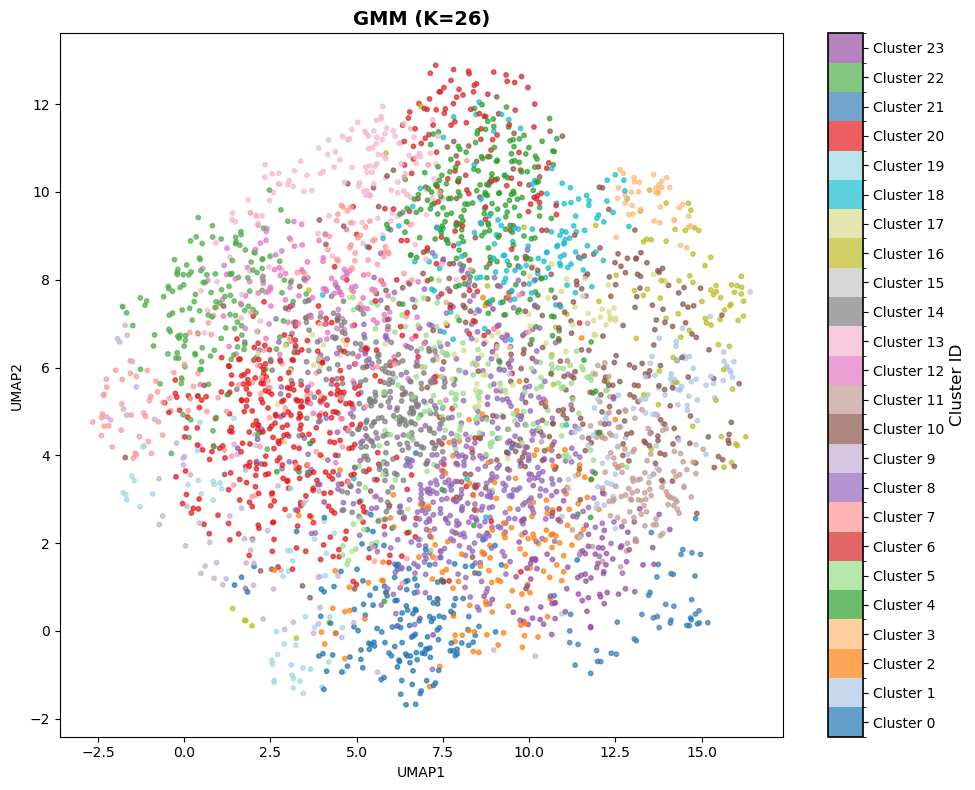

d:\Anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Shubai\AppData\Local\Temp\ipykernel_7160\247217771.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(name)


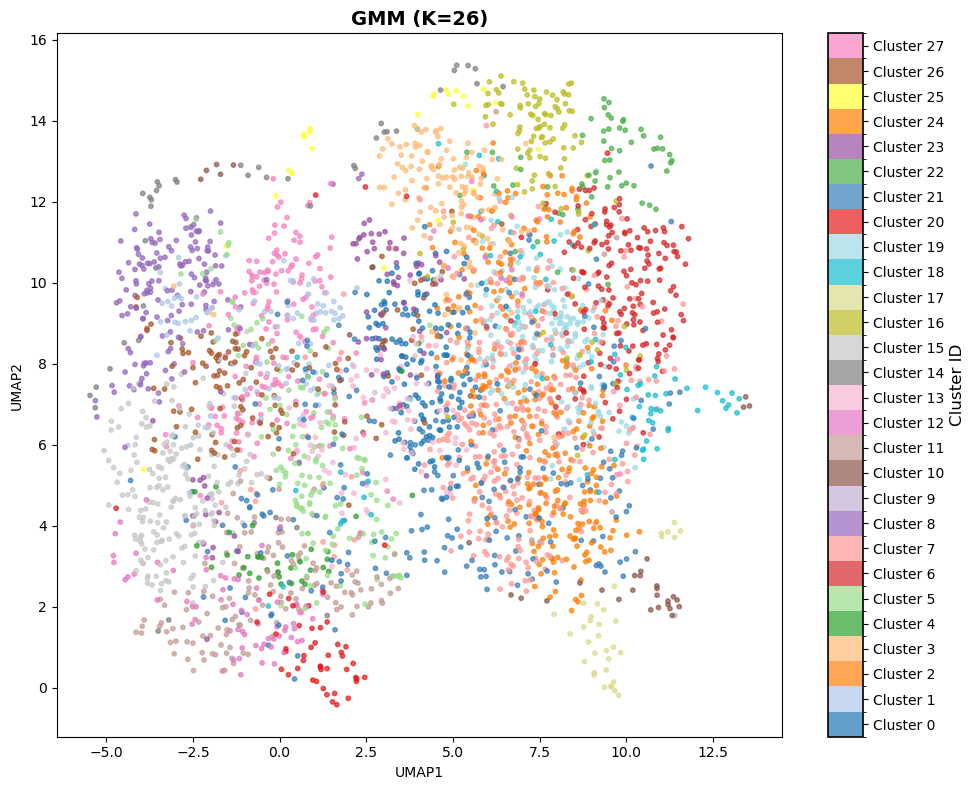

In [ ]:
UMAP_visualization(features_pca1, labels1)
UMAP_visualization(features_pca2, labels2)

In [61]:
features_pca_all = np.vstack((features_pca1 ,features_pca2))
labels_all = BIC_iteration_GMM(features_pca_all)
UMAP_visualization(features_pca_all, labels_all)

KeyboardInterrupt: 

In [ ]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

def extract_clip(video_path, data, timestamps, t_start, t_end, output_dir, fs=100.0):
    """
    从视频中截取指定时间范围的片段，并生成对应 IMU 数据图。
    
    参数
    ----
    video_path : str
    data : np.ndarray, shape (n, 12)
        [aGx,aGy,aGz, anGx,anGy,anGz, wx,wy,wz, roll,pitch,yaw]
    timestamps : np.ndarray, shape (n,)
    t_start, t_end : float
        截取起止时间（单位与 timestamps 一致）
    output_dir : str
    fs : float
        采样率，用于计算时长
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. 截取 IMU 数据
    times = np.asarray(timestamps).flatten()
    idx0 = np.searchsorted(times, t_start)
    idx1 = np.searchsorted(times, t_end)
    idx0 = max(0, idx0)
    idx1 = min(len(times), idx1)
    
    seg_data = data[idx0:idx1]
    seg_times = times[idx0:idx1]
    seg_duration = (idx1 - idx0) / fs
    
    # 2. 截取视频
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    f0 = max(0, int(np.floor(t_start * fps)))
    f1 = min(total_frames, int(np.ceil(t_end * fps)) + 1)
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
    ret, frame = cap.read()
    if not ret:
        cap.release()
        return
    
    h, w = frame.shape[:2]
    out_video = os.path.join(output_dir, f"clip_{t_start:.1f}s_{t_end:.1f}s.mp4")
    writer = cv2.VideoWriter(out_video, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    writer.write(frame)
    
    for _ in range(f1 - f0 - 1):
        ret, frame = cap.read()
        if not ret:
            break
        writer.write(frame)
    
    writer.release()
    cap.release()
    
    # 3. 绘制数据图
    t_rel = np.arange(len(seg_data)) / fs
    fig_width = max(5.0, seg_duration * 3.0)
    fig, axes = plt.subplots(2, 1, figsize=(fig_width, 5.5), sharex=True)
    
    colors_aG = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for ch in range(3):
        axes[0].plot(t_rel, seg_data[:, ch], color=colors_aG[ch], lw=1.2, label=f'aG_{ch}')
    axes[0].set_ylabel('aG (g)')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    colors_w = ['#d62728', '#9467bd', '#8c564b']
    for ch in range(3):
        axes[1].plot(t_rel, seg_data[:, ch + 3], color=colors_w[ch], lw=1.2, label=f'ω_{ch}')
    axes[1].set_ylabel('ω (°/s)')
    axes[1].set_xlabel('Time (s)')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, seg_duration)
    
    plt.tight_layout()
    out_plot = os.path.join(output_dir, f"clip_{t_start:.1f}s_{t_end:.1f}s_signal.png")
    plt.savefig(out_plot, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"Video: {out_video}")
    print(f"Plot:  {out_plot}")
    print(f"Duration: {seg_duration:.2f}s, Frames: {f1-f0}, Samples: {idx1-idx0}")


# ========== 使用示例 ==========
extract_clip(
    video_path="F:/IMU_computational_ethology/Data/2mouse/data2_batch.mp4",
    data= imu_a,
    timestamps= ta_p,
    t_start=120,
    t_end=420,
    output_dir="F:/IMU_computational_ethology/Data/2mouse",
    fs=fs1
)

Video: F:/IMU_computational_ethology/Data/2mouse\clip_120.0s_420.0s.mp4
Plot:  F:/IMU_computational_ethology/Data/2mouse\clip_120.0s_420.0s_signal.png
Duration: 299.99s, Frames: 8993, Samples: 29786


In [142]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


def render_dual_mouse_cluster_video(
    video_path,
    data1_segments, t1, labels1,
    data2_segments, t2, labels2,
    window_sec=4.0, step=2, plot_dpi=80,
    ylim_fixed=None
):
    """
    将两只小鼠各自的信号与聚类标签上下排列，合成到视频下方。
    取消 HMM State，仅显示聚类标签；两鼠时间戳/数据相互独立。
    
    Parameters
    ----------
    video_path : str
        输入视频路径
    data1_segments, data2_segments : list of ndarray
        两鼠原始信号分段，每段 (n_samples, n_channels)
    t1, t2 : ndarray
        两鼠无分段时间戳，长度与各自原始信号总长一致
    labels1, labels2 : ndarray
        两鼠聚类标签，长度与各自 data_segments 一致
    window_sec : float
        信号窗口时长（秒）
    step : int
        每 step 帧渲染一次（降低输出帧率）
    plot_dpi : int
        matplotlib 渲染分辨率
    ylim_fixed : tuple or None
        若提供 (ymin, ymax)，则两鼠信号图固定此范围；否则按当前窗口动态自适应
    """
    # ---------- 1. 展开全局数据 ----------
    full_data1 = np.vstack(data1_segments)
    full_t1 = np.asarray(t1).flatten()
    full_t1 = full_t1 - full_t1[0]          # 归一化到 0 起始
    
    full_data2 = np.vstack(data2_segments)
    full_t2 = np.asarray(t2).flatten()
    full_t2 = full_t2 - full_t2[0]
    
    n_total1 = len(full_t1)
    n_total2 = len(full_t2)
    
    # ---------- 2. 计算每段时间区间 ----------
    seg_info1 = []
    idx = 0
    for i, seg in enumerate(data1_segments):
        m = len(seg)
        t_s = full_t1[idx]
        t_e = full_t1[idx + m - 1] if m > 1 else full_t1[idx]
        seg_info1.append({
            't_start': float(t_s), 't_end': float(t_e),
            'label': int(labels1[i]), 'seg_id': i
        })
        idx += m
    
    seg_info2 = []
    idx = 0
    for i, seg in enumerate(data2_segments):
        m = len(seg)
        t_s = full_t2[idx]
        t_e = full_t2[idx + m - 1] if m > 1 else full_t2[idx]
        seg_info2.append({
            't_start': float(t_s), 't_end': float(t_e),
            'label': int(labels2[i]), 'seg_id': i
        })
        idx += m
    
    # ---------- 3. 视频信息 ----------
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"无法打开视频: {video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    out_path = os.path.join(dir_name, "dual_mouse_" + base_name)
    
    wave_h = 280          # 单鼠信号图高度
    progress_h = 70       # 底部进度条高度
    total_plot_h = wave_h * 2 + progress_h
    
    out_fps = fps / step
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h + total_plot_h))
    
    half = window_sec / 2.0
    t_start = 0.0
    t_end = max(full_t1[-1] if n_total1 > 0 else 0.0,
                full_t2[-1] if n_total2 > 0 else 0.0)
    
    # ---------- 4. 颜色映射 ----------
    unique1 = sorted(set(labels1))
    unique2 = sorted(set(labels2))
    cmap1 = plt.cm.get_cmap('tab20', max(len(unique1), 20))
    cmap2 = plt.cm.get_cmap('tab20b', max(len(unique2), 20))
    colors1 = {k: cmap1(i) for i, k in enumerate(unique1)}
    colors2 = {k: cmap2(i) for i, k in enumerate(unique2)}
    
    # ---------- 5. 预计算每帧对应段索引 ----------
    n_frames = total_frames
    frame_times = (np.arange(n_frames) + 0.5) / fps
    
    # Mouse1
    s1_starts = np.array([s['t_start'] for s in seg_info1])
    s1_ends   = np.array([s['t_end']   for s in seg_info1])
    s1_labels = np.array([s['label']  for s in seg_info1])
    s1_ids    = np.array([s['seg_id']  for s in seg_info1])
    
    fseg1 = np.searchsorted(s1_starts, frame_times, side='right') - 1
    fseg1 = np.clip(fseg1, 0, len(seg_info1) - 1)
    valid1 = (frame_times >= s1_starts[fseg1]) & (frame_times <= s1_ends[fseg1])
    fseg1[~valid1] = -1
    
    # Mouse2
    s2_starts = np.array([s['t_start'] for s in seg_info2])
    s2_ends   = np.array([s['t_end']   for s in seg_info2])
    s2_labels = np.array([s['label']  for s in seg_info2])
    s2_ids    = np.array([s['seg_id']  for s in seg_info2])
    
    fseg2 = np.searchsorted(s2_starts, frame_times, side='right') - 1
    fseg2 = np.clip(fseg2, 0, len(seg_info2) - 1)
    valid2 = (frame_times >= s2_starts[fseg2]) & (frame_times <= s2_ends[fseg2])
    fseg2[~valid2] = -1
    
    # ---------- 6. 逐帧渲染 ----------
    process_frames = np.arange(0, total_frames, step)
    
    for fi in tqdm(process_frames, desc="Rendering", total=len(process_frames)):
        t = fi / fps
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            continue
        
        # ---- 查找窗口数据 ----
        i0_1 = max(0, np.searchsorted(full_t1, t - half))
        i1_1 = min(n_total1, np.searchsorted(full_t1, t + half))
        tw1 = full_t1[i0_1:i1_1]
        dw1 = full_data1[i0_1:i1_1, :]
        
        i0_2 = max(0, np.searchsorted(full_t2, t - half))
        i1_2 = min(n_total2, np.searchsorted(full_t2, t + half))
        tw2 = full_t2[i0_2:i1_2]
        dw2 = full_data2[i0_2:i1_2, :]
        
        # ---- 当前段信息 ----
        seg_idx1 = fseg1[fi] if fi < len(fseg1) else -1
        seg_idx2 = fseg2[fi] if fi < len(fseg2) else -1
        
        curr_lab1 = int(s1_labels[seg_idx1]) if seg_idx1 >= 0 else -1
        curr_lab2 = int(s2_labels[seg_idx2]) if seg_idx2 >= 0 else -1
        curr_id1  = int(s1_ids[seg_idx1])    if seg_idx1 >= 0 else -1
        curr_id2  = int(s2_ids[seg_idx2])    if seg_idx2 >= 0 else -1
        
        # ---- 绘图 ----
        fig = plt.figure(figsize=(w / 150, total_plot_h / 150), dpi=plot_dpi)
        gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.30], hspace=0.06)
        
        ax1 = fig.add_subplot(gs[0])   # Mouse1
        ax2 = fig.add_subplot(gs[1])   # Mouse2
        ax3 = fig.add_subplot(gs[2])   # 双层进度条
        
        # ===== Mouse1 信号 =====
        has_data1 = len(tw1) >= 2 and dw1.shape[0] >= 2
        if has_data1:
            cols = ['#1f77b4', '#ff7f0e', '#2ca02c']
            for ch in range(min(3, dw1.shape[1])):
                ax1.plot(tw1, dw1[:, ch], color=cols[ch], lw=1.1, label=f'Ch{ch+1}')
            ax1.axvline(t, color='red', lw=2, zorder=5)
            for s in seg_info1:
                if t - half <= s['t_start'] <= t + half:
                    ax1.axvline(s['t_start'], color='black', linestyle='--', lw=0.7, alpha=0.4)
            
            if ylim_fixed is not None:
                ax1.set_ylim(ylim_fixed)
            else:
                y_min = np.nanpercentile(dw1[:, :min(3, dw1.shape[1])], 1)
                y_max = np.nanpercentile(dw1[:, :min(3, dw1.shape[1])], 99)
                margin = (y_max - y_min) * 0.1
                ax1.set_ylim(y_min - margin, y_max + margin)
        else:
            ax1.text(0.5, 0.5, 'No Data', transform=ax1.transAxes,
                     ha='center', va='center', fontsize=14, color='gray')
        
        ax1.set_xlim(t - half, t + half)
        ax1.set_ylabel('Mouse1', fontsize=11, fontweight='bold')
        ax1.set_xticks([])
        ax1.legend(loc='upper left', fontsize=7, ncol=3)
        
        if curr_lab1 >= 0:
            c1 = colors1.get(curr_lab1, 'yellow')
            ax1.text(0.98, 0.95, f"Seg {curr_id1} | Cluster {curr_lab1}",
                     transform=ax1.transAxes, fontsize=13, color='darkred',
                     fontweight='bold', ha='right', va='top',
                     bbox=dict(boxstyle='round,pad=0.4', facecolor=c1, alpha=0.85,
                               edgecolor='darkred', linewidth=2))
        
        # ===== Mouse2 信号 =====
        has_data2 = len(tw2) >= 2 and dw2.shape[0] >= 2
        if has_data2:
            cols = ['#d62728', '#9467bd', '#8c564b']
            for ch in range(min(3, dw2.shape[1])):
                ax2.plot(tw2, dw2[:, ch], color=cols[ch], lw=1.1, label=f'Ch{ch+1}')
            ax2.axvline(t, color='red', lw=2, zorder=5)
            for s in seg_info2:
                if t - half <= s['t_start'] <= t + half:
                    ax2.axvline(s['t_start'], color='black', linestyle='--', lw=0.7, alpha=0.4)
            
            if ylim_fixed is not None:
                ax2.set_ylim(ylim_fixed)
            else:
                y_min = np.nanpercentile(dw2[:, :min(3, dw2.shape[1])], 1)
                y_max = np.nanpercentile(dw2[:, :min(3, dw2.shape[1])], 99)
                margin = (y_max - y_min) * 0.1
                ax2.set_ylim(y_min - margin, y_max + margin)
        else:
            ax2.text(0.5, 0.5, 'No Data', transform=ax2.transAxes,
                     ha='center', va='center', fontsize=14, color='gray')
        
        ax2.set_xlim(t - half, t + half)
        ax2.set_ylabel('Mouse2', fontsize=11, fontweight='bold')
        ax2.set_xlabel('Time (s)', fontsize=10)
        ax2.legend(loc='upper left', fontsize=7, ncol=3)
        
        if curr_lab2 >= 0:
            c2 = colors2.get(curr_lab2, 'yellow')
            ax2.text(0.98, 0.95, f"Seg {curr_id2} | Cluster {curr_lab2}",
                     transform=ax2.transAxes, fontsize=13, color='darkred',
                     fontweight='bold', ha='right', va='top',
                     bbox=dict(boxstyle='round,pad=0.4', facecolor=c2, alpha=0.85,
                               edgecolor='darkred', linewidth=2))
        
        # ===== 底部双层进度条 =====
        ax3.set_xlim(t_start, t_end)
        ax3.set_ylim(0, 1)
        ax3.axis('off')
        
        # Mouse1 进度条 (上层 y=0.52~1.0)
        for s in seg_info1:
            c = colors1.get(s['label'], 'gray')
            ax3.axvspan(s['t_start'], s['t_end'], ymin=0.52, ymax=1.0,
                        color=c, alpha=0.75, zorder=1)
        
        # Mouse2 进度条 (下层 y=0.0~0.48)
        for s in seg_info2:
            c = colors2.get(s['label'], 'gray')
            ax3.axvspan(s['t_start'], s['t_end'], ymin=0.0, ymax=0.48,
                        color=c, alpha=0.75, zorder=1)
        
        # 当前窗口高亮 + 红线
        ax3.axvspan(t - half, t + half, color='white', alpha=0.20, zorder=2)
        ax3.axvline(t, color='red', lw=2, zorder=5)
        
        # 文字标注
        ax3.text(t_start + (t_end - t_start) * 0.015, 0.76, 'Mouse1 Cluster',
                 fontsize=9, va='center', color='white', fontweight='bold')
        ax3.text(t_start + (t_end - t_start) * 0.015, 0.24, 'Mouse2 Cluster',
                 fontsize=9, va='center', color='white', fontweight='bold')
        
        # 时间刻度
        ax3.set_xticks(np.linspace(t_start, t_end, 5))
        ax3.set_xticklabels([f'{x:.1f}s' for x in np.linspace(t_start, t_end, 5)], fontsize=8)
        
        # ===== 转 OpenCV =====
        fig.canvas.draw()
        buf = fig.canvas.buffer_rgba()
        plot_img = np.frombuffer(buf, dtype=np.uint8)
        plot_img = plot_img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plot_img = plot_img[:, :, :3]
        plot_img = cv2.cvtColor(plot_img, cv2.COLOR_RGB2BGR)
        plt.close(fig)
        
        if plot_img.shape[1] != w or plot_img.shape[0] != total_plot_h:
            plot_img = cv2.resize(plot_img, (w, total_plot_h))
        
        combined = np.vstack([frame, plot_img])
        out.write(combined)
    
    # ---------- 7. 收尾 ----------
    out.release()
    cap.release()
    print(f"\nSaved: {out_path}")
    return out_path


# ============================================================
# 使用示例
# ============================================================

# 假设已有变量：
# data1_CPDsegments, data2_CPDsegments : list of ndarray
# t1_CPDsegments, t2_CPDsegments       : ndarray
# labels1, labels2                     : ndarray (与段数相同)

out = render_dual_mouse_cluster_video(
    video_path='F:/IMU_computational_ethology/Data/2mouse/clip_120.0s_420.0s.mp4',
    data1_segments=data1_CPDsegments,
    t1=t1_CPDsegments,
    labels1=labels1,
    data2_segments=data2_CPDsegments,
    t2=t2_CPDsegments,
    labels2=labels2,
    window_sec=6.0,
    step=2,
    ylim_fixed=None   # 设为 (-2, 2) 可固定y轴
)


C:\Users\Shubai\AppData\Local\Temp\ipykernel_20072\738029677.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = plt.cm.get_cmap('tab20', max(len(unique1), 20))
C:\Users\Shubai\AppData\Local\Temp\ipykernel_20072\738029677.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = plt.cm.get_cmap('tab20b', max(len(unique2), 20))
Rendering:  81%|████████  | 3641/4497 [1:08:43<16:33,  1.16s/it]C:\Users\Shubai\AppData\Local\Temp\ipykernel_20072\738029677.py:201: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument


Saved: F:/IMU_computational_ethology/Data/2mouse\dual_mouse_clip_120.0s_420.0s.mp4


In [82]:
import numpy as np

def segment_info_to_dict(labels, timestamps, data_segments):
    """
    将 DISSeCT 变点检测的输出整合为每段信息的字典列表。
    
    Parameters
    ----------
    labels : np.ndarray, shape (n_segments,)
        每段的 GMM 聚类标签（整数）。
    timestamps : np.ndarray, shape (n_total_samples,)
        原始未分割的时间戳（秒），总长度等于所有片段采样点数之和。
    data_segments : list of np.ndarray
        变点切割后的片段集合，每个元素 shape 为 (L_i, n_features)。
        L_i 为第 i 个片段包含的原始采样点数。
        
    Returns
    -------
    segment_dicts : list of dict
        每个字典包含一段的：
        - 'segment_id': 片段序号
        - 'label': 聚类标签
        - 'n_samples': 数据点数量（帧数）
        - 'duration_s': 时间长度（秒）
        - 't_start': 起始时间戳
        - 't_end': 结束时间戳
    """
    n_segments = len(labels)
    seg_lengths = [seg.shape[0] for seg in data_segments]
    
    assert len(data_segments) == n_segments, \
        f"片段数 {len(data_segments)} 与标签数 {n_segments} 不匹配"
    assert sum(seg_lengths) == len(timestamps), \
        f"片段总采样点数 {sum(seg_lengths)} 与时间戳长度 {len(timestamps)} 不匹配"
    
    segment_dicts = []
    idx = 0  # 当前片段在时间戳中的起始索引
    
    for i in range(n_segments):
        L = seg_lengths[i]
        
        # 截取该段对应的时间戳区间
        t_segment = timestamps[idx : idx + L]
        t_start = float(t_segment[0])
        t_end = float(t_segment[-1])
        duration = t_end - t_start
        
        # 如果该段只有1个点，duration可能为0，此时用采样间隔估算
        if duration == 0 and L > 0:
            # 尝试用全局平均采样间隔作为后备
            dt = np.median(np.diff(timestamps)) if len(timestamps) > 1 else 0.01
            duration = (L - 1) * dt
        
        info = {
            'segment_id': i,
            'label': int(labels[i]),
            'n_samples': int(L),
            'duration_s': float(duration),
            't_start': t_start,
            't_end': t_end
        }
        segment_dicts.append(info)
        idx += L
    
    return segment_dicts


# =============================================================================
# 使用示例
# =============================================================================

if __name__ == "__main__":
    # 运行
    seg_info1 = segment_info_to_dict(labels1, t1_CPDsegments, data1_CPDsegments)
    
    # 打印结果
    print(f"{'ID':>4} {'Label':>5} {'Samples':>8} {'Duration(s)':>12} "
          f"{'t_start':>10} {'t_end':>10}")
    print("-" * 55)
    for d in seg_info1:
        print(f"{d['segment_id']:>4} {d['label']:>5} {d['n_samples']:>8} "
              f"{d['duration_s']:>12.3f} {d['t_start']:>10.3f} {d['t_end']:>10.3f}")
    seg_info2 = segment_info_to_dict(labels2, t2_CPDsegments, data2_CPDsegments)
    
    # 打印结果
    print(f"{'ID':>4} {'Label':>5} {'Samples':>8} {'Duration(s)':>12} "
          f"{'t_start':>10} {'t_end':>10}")
    print("-" * 55)
    for d in seg_info2:
        print(f"{d['segment_id']:>4} {d['label']:>5} {d['n_samples']:>8} "
              f"{d['duration_s']:>12.3f} {d['t_start']:>10.3f} {d['t_end']:>10.3f}")
    

    


  ID Label  Samples  Duration(s)    t_start      t_end
-------------------------------------------------------
   0    10       12        0.111    120.010    120.121
   1     6       10        0.091    120.131    120.221
   2     0       65        0.645    120.232    120.876
   3     0       33        0.322    120.886    121.208
   4     8       26        0.252    121.219    121.470
   5    10       13        0.121    121.480    121.601
   6     1       16        0.151    121.611    121.762
   7     2       70        0.695    121.773    122.467
   8     8       17        0.161    122.478    122.639
   9     8       35        0.342    122.649    122.991
  10     1       19        0.181    123.001    123.183
  11     0       21        0.201    123.193    123.394
  12    10       17        0.161    123.404    123.565
  13     0       23        0.222    123.575    123.797
  14     8       17        0.161    123.807    123.968
  15     8       35        0.342    123.978    124.321
  16    1

=== Top Co-occurrence ===
  A=20, B=14: 439 frames
  A=9, B=14: 295 frames
  A=21, B=17: 293 frames
  A=20, B=27: 279 frames
  A=20, B=16: 273 frames
  A=20, B=15: 266 frames
  A=20, B=8: 247 frames
  A=20, B=3: 228 frames
  A=8, B=2: 209 frames
  A=2, B=19: 205 frames


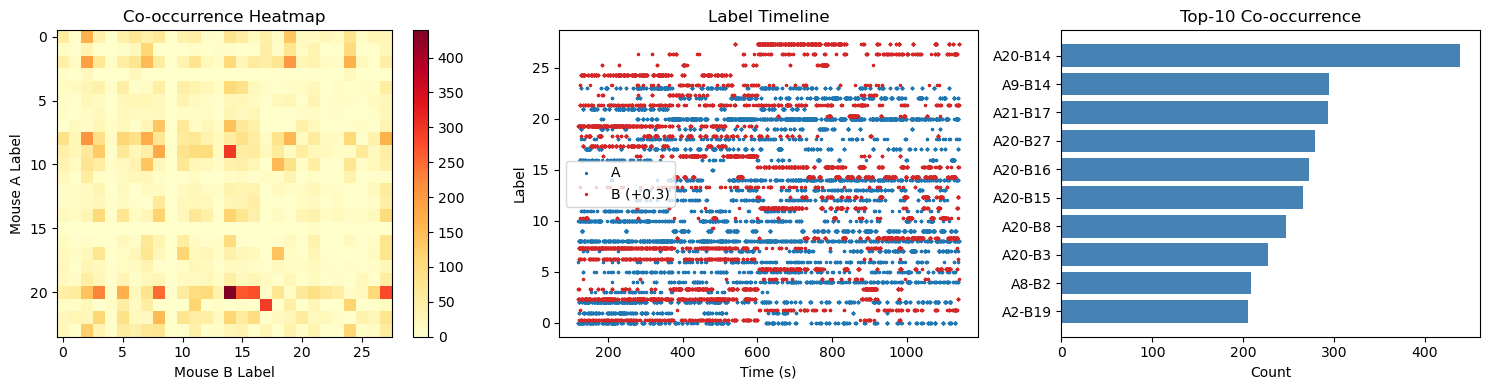

In [84]:
"""
最简社交共现分析：基于 DISSeCT segment 字典列表
输入：segments_A, segments_B（分别聚类，类别数可不同）
输出：高频共现组合 + 可视化
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


# ---------------------------------------------------------
# 1. 对齐到统一时间轴（等间隔采样）
# ---------------------------------------------------------
def segments_to_ts(segs, fs=20, t_max=None):
    """segment 字典列表 -> 等长 label 序列，无覆盖帧=-1"""
    if t_max is None:
        t_max = max(s['t_end'] for s in segs)
    n = int(np.ceil(t_max * fs))
    ts = np.full(n, -1, dtype=int)
    for s in segs:
        ts[int(s['t_start'] * fs):int(np.ceil(s['t_end'] * fs))] = s['label']
    return ts, np.arange(n) / fs


# ---------------------------------------------------------
# 2. 高频共现统计
# ---------------------------------------------------------
def top_cooccurrences(ts_A, ts_B, top_k=10):
    """统计有效帧中的联合标签对频次"""
    mask = (ts_A >= 0) & (ts_B >= 0)
    pairs = list(zip(ts_A[mask], ts_B[mask]))
    counts = Counter(pairs).most_common(top_k)
    return counts  # [((la, lb), count), ...]


# ---------------------------------------------------------
# 3. 可视化
# ---------------------------------------------------------
def plot_social_summary(ts_A, ts_B, times, top_counts, n_A, n_B, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # --- 3.1 共现热力图 ---
    ax1 = axes[0]
    cooc = np.zeros((n_A, n_B), dtype=int)
    for (la, lb), c in Counter(list(zip(ts_A[(ts_A >= 0) & (ts_B >= 0)],
                                        ts_B[(ts_A >= 0) & (ts_B >= 0)]))).items():
        cooc[la, lb] = c
    im = ax1.imshow(cooc, cmap='YlOrRd', aspect='auto')
    ax1.set_xlabel('Mouse B Label')
    ax1.set_ylabel('Mouse A Label')
    ax1.set_title('Co-occurrence Heatmap')
    plt.colorbar(im, ax=ax1)

    # --- 3.2 时间线 ---
    ax2 = axes[1]
    mask = (ts_A >= 0) & (ts_B >= 0)
    ax2.scatter(times[mask], ts_A[mask], s=2, c='C0', label='A')
    ax2.scatter(times[mask], ts_B[mask] + 0.3, s=2, c='C3', label='B (+0.3)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Label')
    ax2.set_title('Label Timeline')
    ax2.legend()

    # --- 3.3 高频组合柱状图 ---
    ax3 = axes[2]
    labels = [f"A{la}-B{lb}" for (la, lb), _ in top_counts]
    vals = [c for _, c in top_counts]
    ax3.barh(range(len(vals)), vals, color='steelblue')
    ax3.set_yticks(range(len(vals)))
    ax3.set_yticklabels(labels)
    ax3.invert_yaxis()
    ax3.set_xlabel('Count')
    ax3.set_title(f'Top-{len(top_counts)} Co-occurrence')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ---------------------------------------------------------
# 4. 主流程（一行调用）
# ---------------------------------------------------------
def analyze(segments_A, segments_B, n_A, n_B, fs=20, top_k=10, save_path=None):
    """
    最简入口。示例：
        analyze(segs_A, segs_B, n_A=6, n_B=8, fs=20, top_k=10)
    """
    t_max = max(max(s['t_end'] for s in segments_A),
                max(s['t_end'] for s in segments_B))
    ts_A, times = segments_to_ts(segments_A, fs, t_max)
    ts_B, _ = segments_to_ts(segments_B, fs, t_max)

    top = top_cooccurrences(ts_A, ts_B, top_k)
    print("=== Top Co-occurrence ===")
    for (la, lb), c in top:
        print(f"  A={la}, B={lb}: {c} frames")

    plot_social_summary(ts_A, ts_B, times, top, n_A, n_B, save_path)
    return {'ts_A': ts_A, 'ts_B': ts_B, 'times': times, 'top': top}


# ---------------------------------------------------------
# 使用示例（取消注释即可运行）
# ---------------------------------------------------------
result = analyze(seg_info1, seg_info2, n_A=24, n_B=28, fs=20, top_k=10)

In [89]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from collections import Counter


def extract_cooccurrence_clips(segments_A, segments_B, video_path, output_dir,
                               n_clips=20, top_k=10, fs=20.0, margin=0.5, min_dur=1.0):
    """
    截取高频共现时段视频，并绘制两组 label 信号对比图。
    所有信息从 segment 字典（t_start, t_end, label）中提取。
    """
    os.makedirs(output_dir, exist_ok=True)

    # ---- 1. 时间轴对齐 ----
    T = max(max(s['t_end'] for s in segments_A), max(s['t_end'] for s in segments_B))
    N = int(np.ceil(T * fs))
    t = np.arange(N) / fs
    A = np.full(N, -1, dtype=int)
    B = np.full(N, -1, dtype=int)

    for s in segments_A:
        A[int(s['t_start'] * fs):int(np.ceil(s['t_end'] * fs))] = s['label']
    for s in segments_B:
        B[int(s['t_start'] * fs):int(np.ceil(s['t_end'] * fs))] = s['label']

    # ---- 2. 高频共现统计 ----
    mask = (A >= 0) & (B >= 0)
    pairs = Counter(list(zip(A[mask], B[mask]))).most_common(top_k)

    # ---- 3. 提取连续区间 ----
    cand = []
    for (la, lb), _ in pairs:
        in_seg, t0 = False, None
        for i in range(N):
            if A[i] == la and B[i] == lb:
                if not in_seg:
                    t0, in_seg = t[i], True
            elif in_seg:
                if t[i - 1] - t0 >= min_dur:
                    cand.append({'p': (la, lb), 't0': max(0, t0 - margin),
                                 't1': t[i - 1] + margin, 'c': t[i - 1] - t0})
                in_seg = False
        if in_seg and t[-1] - t0 >= min_dur:
            cand.append({'p': (la, lb), 't0': max(0, t0 - margin),
                         't1': t[-1] + margin, 'c': t[-1] - t0})

    # 合并重叠区间
    cand.sort(key=lambda x: x['t0'])
    merged = []
    for c in cand:
        if not merged or c['t0'] > merged[-1]['t1'] + 0.1:
            merged.append(c)
        else:
            merged[-1]['t1'] = max(merged[-1]['t1'], c['t1'])
            merged[-1]['p'] = c['p']
    merged.sort(key=lambda x: x['c'], reverse=True)
    sel = merged[:n_clips]

    # ---- 4. 视频参数 ----
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    tot = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    ymax = max(A.max(), B.max()) + 0.5

    # ---- 5. 截取视频 + 绘图 ----
    for idx, s in enumerate(sel):
        t0, t1, (la, lb) = s['t0'], s['t1'], s['p']

        # 视频截取
        cap = cv2.VideoCapture(video_path)
        f0 = max(0, int(np.floor(t0 * fps)))
        f1 = min(tot, int(np.ceil(t1 * fps)) + 1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
        ret, fr = cap.read()
        if not ret:
            cap.release()
            continue

        outv = os.path.join(output_dir, f"{idx:02d}_A{la}B{lb}_{t0:.1f}s_{t1:.1f}s.mp4")
        wr = cv2.VideoWriter(outv, cv2.VideoWriter_fourcc(*'mp4v'), fps, fr.shape[1::-1])
        wr.write(fr)
        for _ in range(f1 - f0 - 1):
            ret, f = cap.read()
            if not ret:
                break
            wr.write(f)
        wr.release()
        cap.release()

        # 两组信号图（label 阶梯图）
        i0, i1 = int(t0 * fs), int(t1 * fs)
        tr = np.arange(i1 - i0) / fs
        a_seg = A[i0:i1]
        b_seg = B[i0:i1]

        fig, ax = plt.subplots(2, 1, figsize=(max(5, (t1 - t0) * 3), 5), sharex=True)

        ax[0].step(tr, a_seg, where='post', color='C0', lw=1.5)
        ax[0].set_ylabel('Mouse A Label')
        ax[0].set_ylim(-0.5, ymax)
        ax[0].grid(True, alpha=0.3)
        ax[0].set_title(f"A={la}, B={lb} | {t0:.2f}s - {t1:.2f}s")

        ax[1].step(tr, b_seg, where='post', color='C3', lw=1.5)
        ax[1].set_ylabel('Mouse B Label')
        ax[1].set_xlabel('Time (s)')
        ax[1].set_ylim(-0.5, ymax)
        ax[1].grid(True, alpha=0.3)

        plt.tight_layout()
        outp = os.path.join(output_dir, f"{idx:02d}_A{la}B{lb}_{t0:.1f}s_{t1:.1f}s.png")
        plt.savefig(outp, dpi=150, bbox_inches='tight')
        plt.close()

        print(f"[{idx + 1}/{len(sel)}] A={la}, B={lb} | {t0:.2f}s-{t1:.2f}s")


# ========== 使用示例 ==========
extract_cooccurrence_clips(
    segments_A= seg_info1,
    segments_B= seg_info2,
    video_path="F:/IMU_computational_ethology/Data/2mouse_imu_83label/data2_batch.mp4",
    output_dir="F:/IMU_computational_ethology/Data/2mouse_imu_83label/clip",
    n_clips=60,
    top_k=50,
    fs=10,
    margin=0.5,
    min_dur=1.0
)



[1/21] A=10, B=18 | 304.40s-307.80s
[2/21] A=17, B=10 | 480.90s-484.00s
[3/21] A=9, B=14 | 840.00s-842.90s
[4/21] A=9, B=14 | 896.60s-899.40s
[5/21] A=10, B=18 | 176.50s-179.00s
[6/21] A=7, B=8 | 1017.90s-1020.40s
[7/21] A=9, B=8 | 950.30s-952.70s
[8/21] A=20, B=15 | 720.40s-722.70s
[9/21] A=9, B=14 | 963.30s-965.60s
[10/21] A=17, B=10 | 140.60s-142.90s
[11/21] A=22, B=14 | 810.20s-812.50s
[12/21] A=9, B=14 | 1071.20s-1074.70s
[13/21] A=20, B=14 | 426.50s-428.70s
[14/21] A=21, B=11 | 669.10s-671.30s
[15/21] A=9, B=8 | 828.70s-830.90s
[16/21] A=9, B=14 | 1050.30s-1052.40s
[17/21] A=21, B=11 | 691.70s-693.80s
[18/21] A=9, B=12 | 1093.20s-1095.30s
[19/21] A=9, B=14 | 377.20s-381.40s
[20/21] A=20, B=14 | 554.20s-556.20s
[21/21] A=20, B=14 | 851.90s-853.90s


In [ ]:
"""
联合 HMM / HSMM 社交行为建模
将 (A_label, B_label) 组合为联合状态，从众多联合 cluster 中推断少数 HMM/HSMM 隐状态。
"""

import numpy as np
from collections import Counter, defaultdict
from itertools import product

# ============================================================
# 0. 依赖
# ============================================================
try:
    from hmmlearn import hmm
    HAS_HMMLEARN = True
except ImportError:
    HAS_HMMLEARN = False
    print("[Warning] hmmlearn not installed. Only HSMM fallback available.")


# ============================================================
# 1. 构建联合 Segment（处理边界对齐）
# ============================================================

def build_combined_segments(segments_A, segments_B):
    """
    将两段 segment 按边界交集对齐，生成联合 segment 列表。
    每个联合 segment 的 label 为 (A_label, B_label)。

    示例：
        A: [0, 1.2) label=0, [1.2, 3.0) label=1
        B: [0, 0.8) label=2, [0.8, 2.5) label=3, [2.5, 3.0) label=4
        输出：
            [0, 0.8):  (0, 2)
            [0.8, 1.2): (0, 3)
            [1.2, 2.5): (1, 3)
            [2.5, 3.0): (1, 4)
    """
    # 收集所有边界
    boundaries = set([0.0])
    for s in segments_A:
        boundaries.add(s['t_start'])
        boundaries.add(s['t_end'])
    for s in segments_B:
        boundaries.add(s['t_start'])
        boundaries.add(s['t_end'])
    boundaries = sorted(boundaries)

    def find_label_at(t, segments):
        """找到覆盖时间点 t 的 segment label"""
        for s in segments:
            if s['t_start'] <= t < s['t_end']:
                return s['label']
        return -1

    combined = []
    for i in range(len(boundaries) - 1):
        t0, t1 = boundaries[i], boundaries[i + 1]
        if t1 - t0 < 1e-6:
            continue
        t_mid = (t0 + t1) / 2
        la = find_label_at(t_mid, segments_A)
        lb = find_label_at(t_mid, segments_B)
        if la >= 0 and lb >= 0:
            combined.append({
                'label': (la, lb),
                't_start': t0,
                't_end': t1,
                'duration_s': t1 - t0
            })
    return combined


# ============================================================
# 2. 过滤与紧凑编码
# ============================================================

def filter_and_encode_combined(combined_segments,
                                min_total_duration=1.0,
                                min_count=3):
    """
    过滤低频/短时长联合状态，重新编码为紧凑整数索引。

    Parameters
    ----------
    min_total_duration : float
        联合状态的最小总出现时长（秒），低于此值的被过滤
    min_count : int
        联合状态的最小出现次数

    Returns
    -------
    filtered : list[dict]
        带有 'joint_idx' 字段的联合 segment 列表
    idx_to_label : dict
        {int: (la, lb)} 解码映射
    """
    dur_stats = defaultdict(float)
    cnt_stats = defaultdict(int)
    for s in combined_segments:
        dur_stats[s['label']] += s['duration_s']
        cnt_stats[s['label']] += 1

    valid_labels = set()
    for lbl in dur_stats:
        if dur_stats[lbl] >= min_total_duration and cnt_stats[lbl] >= min_count:
            valid_labels.add(lbl)

    print(f"[Filter] {len(valid_labels)}/{len(dur_stats)} joint labels retained "
          f"(dur>={min_total_duration}s, count>={min_count})")

    # 紧凑编码
    idx_to_label = {i: lbl for i, lbl in enumerate(sorted(valid_labels))}
    label_to_idx = {lbl: i for i, lbl in idx_to_label.items()}

    filtered = []
    for s in combined_segments:
        if s['label'] in valid_labels:
            s['joint_idx'] = label_to_idx[s['label']]
            filtered.append(s)
    return filtered, idx_to_label


# ============================================================
# 3. 方案 A：标准 HMM（DISSeCT 风格，hmmlearn）
# ============================================================

def combined_to_frames(combined_segments, fs=20, t_max=None):
    """将联合 segment 展开为等长帧序列（供 CategoricalHMM 使用）"""
    if t_max is None:
        t_max = max(s['t_end'] for s in combined_segments)
    n_frames = int(np.ceil(t_max * fs))
    frames = np.full(n_frames, -1, dtype=int)
    for s in combined_segments:
        i0 = int(s['t_start'] * fs)
        i1 = int(np.ceil(s['t_end'] * fs))
        frames[i0:i1] = s['joint_idx']
    return frames


def fit_joint_hmm(frames, n_obs, n_states_range=range(2, 16), n_restarts=5):
    """
    训练 CategoricalHMM，BIC 选状态数。
    与 DISSeCT 原文一致：对每个候选状态数做多次随机初始化，取最优。
    """
    if not HAS_HMMLEARN:
        raise ImportError("hmmlearn is required for standard HMM.")

    valid = frames >= 0
    X = frames[valid].reshape(-1, 1)
    lengths = [len(X)]

    best_bic = np.inf
    best_model = None
    best_n = 2

    for n in n_states_range:
        best_local_score = -np.inf
        best_local_model = None

        for _ in range(n_restarts):
            model = hmm.CategoricalHMM(
                n_components=n,
                n_iter=200,
                tol=1e-3,
                random_state=np.random.randint(0, 10000),
                init_params='ste'  # 自动初始化 startprob, transmat, emissionprob
            )
            model.n_features = n_obs
            model.fit(X, lengths=lengths)

            score = model.score(X, lengths=lengths)
            if score > best_local_score:
                best_local_score = score
                best_local_model = model

        # BIC = -2*loglik + k*log(N)
        loglik = best_local_score
        n_params = n * n + n * n_obs  # 转移矩阵 + 发射矩阵
        bic = -2 * loglik + n_params * np.log(len(X))

        print(f"  n_states={n:2d}, loglik={loglik:10.1f}, BIC={bic:10.1f}")

        if bic < best_bic:
            best_bic = bic
            best_n = n
            best_model = best_local_model

    print(f"[HMM] Best n_states={best_n}, BIC={best_bic:.1f}")
    return best_model, best_n


def decode_hmm_states(model, frames):
    """Viterbi 解码，返回帧级别的 HMM 隐状态序列"""
    valid = frames >= 0
    X = frames[valid].reshape(-1, 1)
    hmm_states = model.predict(X)
    return hmm_states


# ============================================================
# 4. 方案 B：简化 HSMM（显式利用 segment duration）
# ============================================================
# 标准 HMM 假设状态持续时间服从几何分布，这与行为 segment 的实际时长分布不符。
# HSMM 显式建模 sojourn duration，更适合变长 segment。

class SimpleSegmentHSMM:
    """
    基于 segment 序列的简化 HSMM。
    观测：联合标签（离散）
    隐状态：社交行为状态
    关键：显式建模每个隐状态的持续时间分布（非参数直方图）。
    """

    def __init__(self, n_states, n_obs, max_dur_frames=100):
        self.n_states = n_states
        self.n_obs = n_obs
        self.max_dur = max_dur_frames

        # 转移矩阵（不含自转移，因为 HSMM 中离开后才转移）
        self.A = np.ones((n_states, n_states)) / n_states
        np.fill_diagonal(self.A, 0)
        self.A = self.A / self.A.sum(axis=1, keepdims=True)

        # 发射概率 P(obs | state)
        self.B = np.ones((n_states, n_obs)) / n_obs
        self.B = self.B / self.B.sum(axis=1, keepdims=True)

        # 持续时间分布 P(dur | state)，离散化直方图
        self.D = np.ones((n_states, max_dur_frames)) / max_dur_frames
        self.D = self.D / self.D.sum(axis=1, keepdims=True)

    def fit(self, segments, n_iter=30):
        """
        基于 segment 的近似 Baum-Welch。
        输入：segment 列表，每个包含 'joint_idx' 和 'duration_s'
        """
        # 将 duration 转换为帧数（假设 20Hz）
        dur_frames = [min(int(s['duration_s'] * 20), self.max_dur - 1) + 1
                      for s in segments]
        obs_seq = [s['joint_idx'] for s in segments]

        for it in range(n_iter):
            # E-step: 前向-后向（segment 级别，每个 segment 是一个"超观测"）
            alpha = np.zeros((len(segments), self.n_states))
            beta = np.zeros((len(segments), self.n_states))
            scale = np.zeros(len(segments))

            # 前向
            for t in range(len(segments)):
                o = obs_seq[t]
                d = dur_frames[t]
                if t == 0:
                    alpha[t] = self.B[:, o] * self.D[:, d - 1]
                else:
                    alpha[t] = self.B[:, o] * self.D[:, d - 1] * (self.A.T @ alpha[t - 1])
                scale[t] = alpha[t].sum() + 1e-9
                alpha[t] /= scale[t]

            # 后向
            beta[-1] = 1.0
            for t in range(len(segments) - 2, -1, -1):
                o_next = obs_seq[t + 1]
                d_next = dur_frames[t + 1]
                beta[t] = self.A @ (self.B[:, o_next] * self.D[:, d_next - 1] * beta[t + 1])
                beta[t] /= scale[t + 1] + 1e-9

            gamma = alpha * beta
            gamma = gamma / (gamma.sum(axis=1, keepdims=True) + 1e-9)

            # M-step: 更新参数
            # 更新发射概率
            for k in range(self.n_states):
                mask = gamma[:, k] > 0
                if mask.any():
                    for j in range(self.n_obs):
                        self.B[k, j] = (gamma[mask, k] * (np.array(obs_seq)[mask] == j)).sum()
                    self.B[k] += 1e-3  # Laplace smoothing
                    self.B[k] /= self.B[k].sum()

            # 更新持续时间分布
            for k in range(self.n_states):
                mask = gamma[:, k] > 0
                if mask.any():
                    for d in range(1, self.max_dur + 1):
                        self.D[k, d - 1] = (gamma[mask, k] * (np.array(dur_frames)[mask] == d)).sum()
                    self.D[k] += 1e-3
                    self.D[k] /= self.D[k].sum()

            # 更新转移矩阵
            for k in range(self.n_states):
                for l in range(self.n_states):
                    if k != l:
                        xi = 0
                        for t in range(len(segments) - 1):
                            o_next = obs_seq[t + 1]
                            d_next = dur_frames[t + 1]
                            xi += alpha[t, k] * self.A[k, l] * self.B[l, o_next] * self.D[l, d_next - 1] * beta[t + 1, l]
                        self.A[k, l] = xi + 1e-3
                self.A[k] /= self.A[k].sum()

        return self

    def decode(self, segments):
        """Viterbi 解码（segment 级别）"""
        dur_frames = [min(int(s['duration_s'] * 20), self.max_dur - 1) + 1
                      for s in segments]
        obs_seq = [s['joint_idx'] for s in segments]
        T = len(segments)

        delta = np.zeros((T, self.n_states))
        psi = np.zeros((T, self.n_states), dtype=int)

        o0 = obs_seq[0]
        d0 = dur_frames[0]
        delta[0] = np.log(self.B[:, o0] + 1e-9) + np.log(self.D[:, d0 - 1] + 1e-9)

        for t in range(1, T):
            o = obs_seq[t]
            d = dur_frames[t]
            for j in range(self.n_states):
                best = -np.inf
                best_i = 0
                for i in range(self.n_states):
                    if i == j:
                        continue
                    val = delta[t - 1, i] + np.log(self.A[i, j] + 1e-9)
                    if val > best:
                        best = val
                        best_i = i
                delta[t, j] = best + np.log(self.B[j, o] + 1e-9) + np.log(self.D[j, d - 1] + 1e-9)
                psi[t, j] = best_i

        states = np.zeros(T, dtype=int)
        states[-1] = np.argmax(delta[-1])
        for t in range(T - 2, -1, -1):
            states[t] = psi[t + 1, states[t + 1]]
        return states


# ============================================================
# 5. 结果解析：HMM State 的社交语义
# ============================================================

def summarize_hmm_states(hmm_states, combined_segments, idx_to_label,
                         method='hsmm'):
    """
    汇总每个 HMM/HSMM 隐状态对应的原始联合标签分布。

    返回：
        state_info : list[dict]
            每个元素包含：
            - state_id: 隐状态编号
            - total_duration: 该状态的总时长
            - emission_dist: {joint_label: probability} 发射概率分布
            - top_joint_labels: 该状态最可能的几个联合标签对
    """
    if method == 'hmm':
        # 帧级别对齐：需要把 hmm_states 映射回 segment
        # 简化：按 segment 中点对应的帧取状态
        fs = 20
        t_max = max(s['t_end'] for s in combined_segments)
        n_frames = int(np.ceil(t_max * fs))
        frame_to_state = np.full(n_frames, -1, dtype=int)
        frame_to_state[:len(hmm_states)] = hmm_states

        state_durations = defaultdict(float)
        state_emissions = defaultdict(lambda: Counter())

        for s in combined_segments:
            mid_t = (s['t_start'] + s['t_end']) / 2
            f_idx = int(mid_t * fs)
            f_idx = min(f_idx, len(hmm_states) - 1)
            state_id = hmm_states[f_idx]
            if state_id < 0:
                continue
            state_durations[state_id] += s['duration_s']
            state_emissions[state_id][s['label']] += s['duration_s']

    else:  # hsmm
        state_durations = defaultdict(float)
        state_emissions = defaultdict(lambda: Counter())
        for s, state_id in zip(combined_segments, hmm_states):
            state_durations[state_id] += s['duration_s']
            state_emissions[state_id][s['label']] += s['duration_s']

    state_info = []
    for state_id in sorted(state_durations.keys()):
        total_dur = state_durations[state_id]
        emissions = state_emissions[state_id]
        # 归一化为概率
        dist = {lbl: dur / total_dur for lbl, dur in emissions.items()}
        top = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:5]

        state_info.append({
            'state_id': state_id,
            'total_duration': total_dur,
            'emission_dist': dist,
            'top_joint_labels': top
        })

    return state_info


# ============================================================
# 6. 主流程
# ============================================================

def joint_hmm_pipeline(segments_A, segments_B,
                       method='hmm',
                       fs=20,
                       min_total_duration=1.0,
                       min_count=3,
                       n_states_range=range(2, 16),
                       hsmm_n_states=6):
    """
    完整流程：构建联合 segment -> 过滤 -> HMM/HSMM -> 解析。

    Parameters
    ----------
    method : 'hmm' or 'hsmm'
    fs : int
        帧采样率（仅 HMM 使用）
    min_total_duration, min_count : 过滤阈值
    n_states_range : range
        HMM BIC 搜索范围
    hsmm_n_states : int
        HSMM 隐状态数（HSMM 目前不自动选状态数）

    Returns
    -------
    result : dict
    """
    # Step 1: 构建联合 segment
    combined = build_combined_segments(segments_A, segments_B)
    print(f"[Build] {len(combined)} combined segments")

    # Step 2: 过滤与编码
    filtered, idx_to_label = filter_and_encode_combined(
        combined, min_total_duration, min_count
    )
    n_obs = len(idx_to_label)

    if method == 'hmm':
        if not HAS_HMMLEARN:
            raise ImportError("pip install hmmlearn")

        # Step 3a: 展开为帧序列
        frames = combined_to_frames(filtered, fs=fs)
        print(f"[Frames] {len(frames)} frames @ {fs}Hz")

        # Step 4a: HMM 训练 + BIC 选状态数
        model, best_n = fit_joint_hmm(frames, n_obs, n_states_range)

        # Step 5a: Viterbi 解码
        hmm_states = decode_hmm_states(model, frames)

        # Step 6a: 结果解析
        state_info = summarize_hmm_states(hmm_states, filtered, idx_to_label, method='hmm')

        # 额外：发射概率矩阵
        emission_prob = model.emissionprob_

    else:  # hsmm
        # Step 3b: 直接用 segment 序列训练 HSMM
        hsmm = SimpleSegmentHSMM(n_states=hsmm_n_states, n_obs=n_obs)
        hsmm.fit(filtered, n_iter=30)

        # Step 4b: Viterbi 解码
        hmm_states = hsmm.decode(filtered)

        # Step 5b: 结果解析
        state_info = summarize_hmm_states(hmm_states, filtered, idx_to_label, method='hsmm')

        emission_prob = hsmm.B
        model = hsmm
        best_n = hsmm_n_states

    # 打印结果
    print(f"\n=== HMM/HSMM State Summary ({method.upper()}, {best_n} states) ===")
    for info in state_info:
        print(f"\nState {info['state_id']}: total_duration={info['total_duration']:.2f}s")
        print(f"  Top joint labels (A, B -> prob):")
        for (la, lb), p in info['top_joint_labels']:
            print(f"    ({la}, {lb}) -> {p:.3f}")

    return {
        'combined_segments': filtered,
        'idx_to_label': idx_to_label,
        'model': model,
        'hmm_states': hmm_states,
        'n_states': best_n,
        'state_info': state_info,
        'emission_prob': emission_prob
    }


# ============================================================
# 7. 使用示例
# ============================================================
result = joint_hmm_pipeline(
    segments_A=seg_info1,
    segments_B=seg_info2,
    method='hmm',          # 或 'hsmm'
    fs=20,
    min_total_duration=1.0,
    min_count=3,
    n_states_range=range(4, 16),
    hsmm_n_states=6
)
#
# 查看 State 0 的发射概率分布
state0_top = result['state_info'][0]['top_joint_labels']
print("State 0 对应:", state0_top)

[Build] 6725 combined segments
[Filter] 256/562 joint labels retained (dur>=1.0s, count>=3)
[Frames] 22800 frames @ 20Hz
  n_states= 4, loglik=  -79427.2, BIC=  169051.4
  n_states= 5, loglik=  -76133.2, BIC=  165061.6
  n_states= 6, loglik=  -74711.6, BIC=  164836.2
  n_states= 7, loglik=  -73882.3, BIC=  165815.1
  n_states= 8, loglik=  -72234.4, BIC=  165176.4
  n_states= 9, loglik=  -70985.7, BIC=  165355.6
  n_states=10, loglik=  -69107.6, BIC=  164295.7
  n_states=11, loglik=  -68381.9, BIC=  165560.3
  n_states=12, loglik=  -65898.8, BIC=  163329.6
  n_states=13, loglik=  -65254.1, BIC=  164795.2
  n_states=14, loglik=  -65586.0, BIC=  168233.8
  n_states=15, loglik=  -64272.7, BIC=  168401.7
[HMM] Best n_states=12, BIC=163329.6

=== HMM/HSMM State Summary (HMM, 12 states) ===

State 0: total_duration=38.51s
  Top joint labels (A, B -> prob):
    (9, 14) -> 0.052
    (20, 3) -> 0.037
    (20, 16) -> 0.033
    (9, 8) -> 0.029
    (17, 18) -> 0.027

State 1: total_duration=250.40s

In [94]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def visualize_joint_hmm_aligned(result, segments_A, segments_B,
                                  save_dir=None, dpi=150, max_time=120.0):
    """
    对齐到原始时间戳的可视化（不画 original joint）。
    
    假设数据时间戳从 120s 开始，x 轴标记从 120s 起。
    只显示 [t_min, t_min + max_time] 区间。
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    combined = result['combined_segments']
    idx_to_label = result['idx_to_label']
    n_states = result['n_states']
    state_info = result['state_info']
    model = result['model']
    is_hmm = hasattr(model, 'emissionprob_')
    n_joint = len(idx_to_label)

    # 原始时间偏移（数据实际起始时间戳）
    t_min = min(s['t_start'] for s in combined)
    t_max_data = max(s['t_end'] for s in combined)
    t_display_end = min(t_min + max_time, t_max_data)

    # 帧时间轴（绝对时间）
    fs = 20
    N = int(np.ceil((t_display_end - t_min) * fs))
    t_grid = t_min + np.arange(N) / fs

    # HMM 状态时间序列（映射到绝对时间）
    hmm_ts = np.full(N, -1, dtype=int)
    if is_hmm:
        n_decoded = min(len(result['hmm_states']), N)
        hmm_ts[:n_decoded] = result['hmm_states'][:n_decoded]
    else:
        for s, st in zip(combined, result['hmm_states']):
            if s['t_start'] >= t_display_end:
                continue
            i0 = max(0, int((s['t_start'] - t_min) * fs))
            i1 = min(N, int(np.ceil((min(s['t_end'], t_display_end) - t_min) * fs)))
            if i0 < N:
                hmm_ts[i0:i1] = st

    # 鲜艳配色
    state_colors = plt.cm.tab20(np.linspace(0, 1, max(n_states, 20)))[:n_states]

    # ============================================================
    # 布局：3 行
    # ============================================================
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.5, 2.5, 2], hspace=0.35, wspace=0.3)

    # --- 1. HMM State Timeline（绝对时间，从 t_min 开始）---
    ax1 = fig.add_subplot(gs[0, :])
    valid_hmm = hmm_ts >= 0

    for state_id in range(n_states):
        mask = (hmm_ts == state_id) & valid_hmm
        if not mask.any():
            continue
        in_seg = False
        for i in range(N):
            if mask[i] and not in_seg:
                seg_start = i
                in_seg = True
            elif not mask[i] and in_seg:
                ax1.fill_between(t_grid[seg_start:i], state_id - 0.4, state_id + 0.4,
                                 color=state_colors[state_id], alpha=0.95, step='post')
                in_seg = False
        if in_seg:
            ax1.fill_between(t_grid[seg_start:N], state_id - 0.4, state_id + 0.4,
                             color=state_colors[state_id], alpha=0.95, step='post')

    ax1.set_xlim(t_min, t_display_end)
    ax1.set_ylim(-0.5, n_states - 0.5)
    ax1.set_yticks(range(n_states))
    ax1.set_yticklabels([f'State {i}' for i in range(n_states)])
    ax1.set_ylabel('HMM State', fontsize=12)
    ax1.set_xlabel('Time (s)', fontsize=12)
    ax1.set_title(f'Joint HMM State Timeline ({t_min:.0f}s - {t_display_end:.0f}s, {n_states} states)',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')

    # x 轴刻度从 t_min 开始，每 10 秒一个标记
    xticks = np.arange(t_min, t_display_end + 1, 10)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{x:.0f}' for x in xticks])

    # --- 2. 发射概率热力图 ---
    ax2 = fig.add_subplot(gs[1, 0])
    emission = result['emission_prob']
    emission_display = emission.copy()
    emission_display[emission_display < 0.02] = 0

    joint_labels_str = [f"A{la}-B{lb}" for _, (la, lb) in sorted(idx_to_label.items())]

    im = ax2.imshow(emission_display, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax2.set_xticks(range(n_joint))
    ax2.set_xticklabels([joint_labels_str[i] for i in range(n_joint)], rotation=90, fontsize=6)
    ax2.set_yticks(range(n_states))
    ax2.set_yticklabels([f'S{i}' for i in range(n_states)], fontsize=8)
    ax2.set_xlabel('Joint Label (A-B)', fontsize=10)
    ax2.set_ylabel('HMM State', fontsize=10)
    ax2.set_title('Emission P(joint | state)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

    # --- 3. 转移矩阵 ---
    ax3 = fig.add_subplot(gs[1, 1])
    trans = model.transmat_ if is_hmm else model.A
    im2 = ax3.imshow(trans, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    ax3.set_xticks(range(n_states))
    ax3.set_yticks(range(n_states))
    ax3.set_xlabel('To State', fontsize=10)
    ax3.set_ylabel('From State', fontsize=10)
    ax3.set_title('Transition Matrix', fontsize=12, fontweight='bold')

    for i in range(n_states):
        for j in range(n_states):
            if trans[i, j] > 0.1:
                ax3.text(j, i, f'{trans[i,j]:.2f}', ha='center', va='center',
                         fontsize=8, color='white' if trans[i, j] > 0.5 else 'black')
    plt.colorbar(im2, ax=ax3, fraction=0.046, pad=0.04)

    # --- 4. 状态时长分布 ---
    ax4 = fig.add_subplot(gs[1, 2])
    durations = [info['total_duration'] for info in state_info]
    bars = ax4.bar(range(n_states), durations, color=state_colors[:n_states],
                   edgecolor='black', linewidth=0.5)
    ax4.set_xticks(range(n_states))
    ax4.set_xticklabels([f'S{i}' for i in range(n_states)], fontsize=9)
    ax4.set_xlabel('HMM State', fontsize=10)
    ax4.set_ylabel('Total Duration (s)', fontsize=10)
    ax4.set_title('State Duration', fontsize=12, fontweight='bold')

    for bar, dur in zip(bars, durations):
        if dur > max(durations) * 0.05:
            ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                     f'{dur:.1f}s', ha='center', va='bottom', fontsize=7)

    # --- 5. 文字摘要（分栏 + 彩色背景框）---
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')

    n_cols = min(6, n_states)
    n_rows = int(np.ceil(n_states / n_cols))
    cell_w = 1.0 / n_cols
    cell_h = 1.0 / n_rows

    for idx, info in enumerate(state_info):
        col = idx % n_cols
        row = idx // n_cols
        x = col * cell_w + 0.01
        y = 1.0 - (row + 1) * cell_h + 0.01

        lines = [f"State {info['state_id']}: {info['total_duration']:.1f}s"]
        for (la, lb), p in info['top_joint_labels'][:3]:
            lines.append(f"  (A{la},B{lb}): {p:.2f}")

        rect = Rectangle((x, y), cell_w - 0.02, cell_h - 0.02,
                          facecolor=state_colors[info['state_id']], alpha=0.15,
                          edgecolor=state_colors[info['state_id']], linewidth=2,
                          transform=ax5.transAxes)
        ax5.add_patch(rect)

        ax5.text(x + 0.01, y + cell_h - 0.03, "\n".join(lines),
                 transform=ax5.transAxes, fontsize=8, verticalalignment='top',
                 fontfamily='monospace')

    ax5.set_xlim(0, 1)
    ax5.set_ylim(0, 1)
    ax5.set_title('State Semantic Summary (Top-3 Joint Labels)',
                  fontsize=12, fontweight='bold', y=0.98)

    plt.tight_layout()
    if save_dir:
        path = os.path.join(save_dir, 'joint_hmm_aligned.png')
        plt.savefig(path, dpi=dpi, bbox_inches='tight')
        print(f"[Saved] {path}")
    plt.show()


# ========== 使用示例 ==========
visualize_joint_hmm_aligned(
    result=result,
    segments_A=seg_info1,
    segments_B=seg_info2,
    save_dir='F:/IMU_computational_ethology/output/',
    dpi=150,
    max_time=120.0  # 显示前 2 分钟（从 120s 到 240s）
)

[Saved] F:/IMU_computational_ethology/output/joint_hmm_aligned.png


In [71]:
print(seg_info1)
print(seg_info2)

[{'segment_id': 0, 'label': 10, 'n_samples': 12, 'duration_s': 0.1107875073357718, 't_start': 120.00997770163522, 't_end': 120.120765208971}, {'segment_id': 1, 'label': 6, 'n_samples': 10, 'duration_s': 0.0906443241838133, 't_start': 120.13083680054697, 't_end': 120.22148112473079}, {'segment_id': 2, 'label': 0, 'n_samples': 65, 'duration_s': 0.6445818608626723, 't_start': 120.23155271630677, 't_end': 120.87613457716944}, {'segment_id': 3, 'label': 0, 'n_samples': 33, 'duration_s': 0.32229093043133616, 't_start': 120.88620616874542, 't_end': 121.20849709917675}, {'segment_id': 4, 'label': 8, 'n_samples': 26, 'duration_s': 0.2517897893994814, 't_start': 121.21856869075273, 't_end': 121.47035848015221}, {'segment_id': 5, 'label': 10, 'n_samples': 13, 'duration_s': 0.12085909891175106, 't_start': 121.4804300717282, 't_end': 121.60128917063994}, {'segment_id': 6, 'label': 1, 'n_samples': 16, 'duration_s': 0.15107387363968883, 't_start': 121.61136076221592, 't_end': 121.76243463585561}, {'s

In [100]:
import os
import cv2
import numpy as np


# ============================================================
# 1. 修改后的 Pipeline：给每个 combined segment 标注 HMM state
# ============================================================

def joint_hmm_pipeline_with_state(segments_A, segments_B,
                                   method='hmm',
                                   fs=20,
                                   min_total_duration=1.0,
                                   min_count=3,
                                   n_states_range=range(2, 16),
                                   hsmm_n_states=6):
    """
    完整流程，与之前一致，但输出中每个 combined segment 带有 'hmm_state' 字段。
    """
    # Step 1: 构建联合 segment
    combined = build_combined_segments(segments_A, segments_B)
    print(f"[Build] {len(combined)} combined segments")

    # Step 2: 过滤与编码
    filtered, idx_to_label = filter_and_encode_combined(
        combined, min_total_duration, min_count
    )
    n_obs = len(idx_to_label)

    if method == 'hmm':
        if not HAS_HMMLEARN:
            raise ImportError("pip install hmmlearn")

        frames = combined_to_frames(filtered, fs=fs)
        print(f"[Frames] {len(frames)} frames @ {fs}Hz")

        model, best_n = fit_joint_hmm(frames, n_obs, n_states_range)

        # Viterbi 解码（完整帧序列）
        hmm_states = decode_hmm_states_full(model, frames)

        # 关键：给每个 combined segment 标注 HMM state
        for s in filtered:
            mid_t = (s['t_start'] + s['t_end']) / 2
            f_idx = int(mid_t * fs)
            f_idx = min(f_idx, len(hmm_states) - 1)
            s['hmm_state'] = int(hmm_states[f_idx])

        state_info = summarize_hmm_states(hmm_states, filtered, idx_to_label, method='hmm')
        emission_prob = model.emissionprob_

    else:  # hsmm
        hsmm = SimpleSegmentHSMM(n_states=hsmm_n_states, n_obs=n_obs)
        hsmm.fit(filtered, n_iter=30)
        hmm_seg_states = hsmm.decode(filtered)

        # 关键：给每个 combined segment 标注 HMM state
        for s, st in zip(filtered, hmm_seg_states):
            s['hmm_state'] = int(st)

        state_info = summarize_hmm_states(hmm_seg_states, filtered, idx_to_label, method='hsmm')
        emission_prob = hsmm.B
        model = hsmm
        best_n = hsmm_n_states

    print(f"\n=== HMM/HSMM State Summary ({method.upper()}, {best_n} states) ===")
    for info in state_info:
        print(f"\nState {info['state_id']}: total_duration={info['total_duration']:.2f}s")
        print(f"  Top joint labels (A, B -> prob):")
        for (la, lb), p in info['top_joint_labels']:
            print(f"    ({la}, {lb}) -> {p:.3f}")

    return {
        'combined_segments': filtered,
        'idx_to_label': idx_to_label,
        'model': model,
        'hmm_states': hmm_states if method == 'hmm' else hmm_seg_states,
        'n_states': best_n,
        'state_info': state_info,
        'emission_prob': emission_prob
    }


# ============================================================
# 2. 按原始 Segment 截取视频（每个 segment 单独一个文件）
# ============================================================

def extract_state_clips_by_segment(video_path, result, output_dir):
    """
    按原始 combined segment 截取视频。
    每个 segment 单独保存到对应 State 文件夹中。
    打印每段长度和每个 State 的总长。

    要求 result['combined_segments'] 中每个 segment 已有 'hmm_state' 字段。
    """
    os.makedirs(output_dir, exist_ok=True)

    combined = result['combined_segments']
    n_states = result['n_states']

    # 视频参数
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    # 按 State 分组统计
    state_total_dur = {i: 0.0 for i in range(n_states)}
    state_counts = {i: 0 for i in range(n_states)}

    for s in combined:
        st = s['hmm_state']
        state_total_dur[st] += s['duration_s']
        state_counts[st] += 1

    print("\n" + "=" * 50)
    print("State Summary (before extraction)")
    print("-" * 50)
    for st in range(n_states):
        if state_counts[st] > 0:
            print(f"State {st:2d}: {state_counts[st]:3d} segments, {state_total_dur[st]:7.2f}s total")
    print("=" * 50)

    # 逐 segment 截取
    for idx, s in enumerate(combined):
        st = s['hmm_state']
        t0, t1 = s['t_start'], s['t_end']
        dur = s['duration_s']

        state_dir = os.path.join(output_dir, f"State_{st}")
        os.makedirs(state_dir, exist_ok=True)

        # 视频帧索引（严格按原始 segment 时间戳）
        f0 = max(0, int(np.floor(t0 * fps)))
        f1 = min(total_frames, int(np.ceil(t1 * fps)) + 1)

        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
        ret, frame = cap.read()
        if not ret:
            cap.release()
            print(f"  [Skip] Failed to read frame at {t0:.3f}s")
            continue

        out_path = os.path.join(
            state_dir,
            f"seg_{idx:04d}_{t0:.3f}s_{t1:.3f}s_{dur:.3f}s.mp4"
        )
        writer = cv2.VideoWriter(
            out_path,
            cv2.VideoWriter_fourcc(*'mp4v'),
            fps,
            (frame.shape[1], frame.shape[0])
        )
        writer.write(frame)

        for _ in range(f1 - f0 - 1):
            ret, f = cap.read()
            if not ret:
                break
            writer.write(f)

        writer.release()
        cap.release()

        print(f"[State {st}] seg_{idx:04d} | {t0:.3f}s - {t1:.3f}s | duration: {dur:.3f}s")

    # 最终汇总
    print("\n" + "=" * 50)
    print("Extraction Complete")
    print("-" * 50)
    for st in range(n_states):
        if state_counts[st] > 0:
            print(f"State {st:2d}: {state_counts[st]:3d} clips, {state_total_dur[st]:7.2f}s total")
    print("=" * 50)


# ============================================================
# 3. 使用示例
# ============================================================

result = joint_hmm_pipeline_with_state(
    segments_A=seg_info1,
    segments_B=seg_info2,
    method='hmm',
    fs=20,
    min_total_duration=1.0,
    min_count=3,
    n_states_range=range(4, 16)
)

extract_state_clips_by_segment(
    video_path="F:/IMU_computational_ethology/Data/2mouse_imu_83label/data2_batch.mp4",
    result=result,
    output_dir="F:/IMU_computational_ethology/Data/2mouse_imu_83label/states_clip",
)
# ========== 使用示例 ==========


[Build] 6725 combined segments
[Filter] 256/562 joint labels retained (dur>=1.0s, count>=3)
[Frames] 22800 frames @ 20Hz


KeyboardInterrupt: 

In [104]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from scipy.spatial.distance import jensenshannon
from hmmlearn import hmm


# ============================================================
# 1. 构建联合 Segment
# ============================================================

def build_combined_segments(segments_A, segments_B):
    """将两段 segment 按边界交集对齐，生成联合 segment 列表。"""
    boundaries = set([0.0])
    for s in segments_A:
        boundaries.add(s['t_start'])
        boundaries.add(s['t_end'])
    for s in segments_B:
        boundaries.add(s['t_start'])
        boundaries.add(s['t_end'])
    boundaries = sorted(boundaries)

    def find_label_at(t, segments):
        for s in segments:
            if s['t_start'] <= t < s['t_end']:
                return s['label']
        return -1

    combined = []
    for i in range(len(boundaries) - 1):
        t0, t1 = boundaries[i], boundaries[i + 1]
        if t1 - t0 < 1e-6:
            continue
        t_mid = (t0 + t1) / 2
        la = find_label_at(t_mid, segments_A)
        lb = find_label_at(t_mid, segments_B)
        if la >= 0 and lb >= 0:
            combined.append({
                'label': (la, lb),
                't_start': t0,
                't_end': t1,
                'duration_s': t1 - t0
            })
    return combined


# ============================================================
# 2. 过滤与紧凑编码
# ============================================================

def filter_and_encode_combined(combined_segments, min_total_duration=1.0, min_count=3):
    """过滤低频/短时长联合状态，重新编码为紧凑整数索引。"""
    dur_stats = defaultdict(float)
    cnt_stats = defaultdict(int)
    for s in combined_segments:
        dur_stats[s['label']] += s['duration_s']
        cnt_stats[s['label']] += 1

    valid_labels = set()
    for lbl in dur_stats:
        if dur_stats[lbl] >= min_total_duration and cnt_stats[lbl] >= min_count:
            valid_labels.add(lbl)

    print(f"[Filter] {len(valid_labels)}/{len(dur_stats)} joint labels retained")

    idx_to_label = {i: lbl for i, lbl in enumerate(sorted(valid_labels))}
    label_to_idx = {lbl: i for i, lbl in idx_to_label.items()}

    filtered = []
    for s in combined_segments:
        if s['label'] in valid_labels:
            s['joint_idx'] = label_to_idx[s['label']]
            filtered.append(s)
    return filtered, idx_to_label


# ============================================================
# 3. 帧展开
# ============================================================

def combined_to_frames(combined_segments, fs=20, t_max=None):
    """将联合 segment 展开为等长帧序列。"""
    if t_max is None:
        t_max = max(s['t_end'] for s in combined_segments)
    n_frames = int(np.ceil(t_max * fs))
    frames = np.full(n_frames, -1, dtype=int)
    for s in combined_segments:
        i0 = int(s['t_start'] * fs)
        i1 = int(np.ceil(s['t_end'] * fs))
        i0 = max(0, i0)
        i1 = min(n_frames, i1)
        frames[i0:i1] = s['joint_idx']
    return frames


# ============================================================
# 4. HMM 训练（BIC 选状态数）
# ============================================================

def fit_joint_hmm(frames, n_obs, n_states_range=range(2, 16), n_restarts=5):
    """训练 CategoricalHMM，BIC 选状态数。"""
    valid = frames >= 0
    X = frames[valid].reshape(-1, 1)
    lengths = [len(X)]

    best_bic = np.inf
    best_model = None
    best_n = 2

    for n in n_states_range:
        best_local_score = -np.inf
        best_local_model = None

        for _ in range(n_restarts):
            model = hmm.CategoricalHMM(
                n_components=n,
                n_iter=200,
                tol=1e-3,
                random_state=np.random.randint(0, 10000),
                init_params='ste'
            )
            model.n_features = n_obs
            model.fit(X, lengths=lengths)

            score = model.score(X, lengths=lengths)
            if score > best_local_score:
                best_local_score = score
                best_local_model = model

        loglik = best_local_score
        n_params = n * n + n * n_obs
        bic = -2 * loglik + n_params * np.log(len(X))

        print(f"  n_states={n:2d}, loglik={loglik:10.1f}, BIC={bic:10.1f}")

        if bic < best_bic:
            best_bic = bic
            best_n = n
            best_model = best_local_model

    print(f"[HMM] Best n_states={best_n}, BIC={best_bic:.1f}")
    return best_model, best_n


# ============================================================
# 5. 完整帧解码（修复：保留无效帧位置）
# ============================================================

def decode_hmm_states_full(model, frames):
    """
    Viterbi 解码，返回与 frames 等长的完整状态序列（含 -1 占位）。
    索引 i 直接对应绝对时间 i/fs。
    """
    valid = frames >= 0
    X = frames[valid].reshape(-1, 1)
    hmm_states_valid = model.predict(X)

    hmm_states = np.full(len(frames), -1, dtype=int)
    hmm_states[valid] = hmm_states_valid
    return hmm_states


# ============================================================
# 6. 结果汇总
# ============================================================

def summarize_hmm_states(hmm_states, combined_segments, idx_to_label, method='hmm'):
    """汇总每个 HMM 隐状态对应的原始联合标签分布。"""
    fs = 20
    t_max = max(s['t_end'] for s in combined_segments)
    n_frames = int(np.ceil(t_max * fs))

    if method == 'hmm':
        frame_to_state = np.full(n_frames, -1, dtype=int)
        n_copy = min(len(hmm_states), n_frames)
        frame_to_state[:n_copy] = hmm_states[:n_copy]

        state_durations = defaultdict(float)
        state_emissions = defaultdict(lambda: Counter())

        for s in combined_segments:
            mid_t = (s['t_start'] + s['t_end']) / 2
            f_idx = int(mid_t * fs)
            f_idx = min(f_idx, n_frames - 1)
            state_id = frame_to_state[f_idx]
            if state_id < 0:
                continue
            state_durations[state_id] += s['duration_s']
            state_emissions[state_id][s['label']] += s['duration_s']
    else:
        state_durations = defaultdict(float)
        state_emissions = defaultdict(lambda: Counter())
        for s, state_id in zip(combined_segments, hmm_states):
            state_durations[state_id] += s['duration_s']
            state_emissions[state_id][s['label']] += s['duration_s']

    state_info = []
    for state_id in sorted(state_durations.keys()):
        total_dur = state_durations[state_id]
        emissions = state_emissions[state_id]
        dist = {lbl: dur / total_dur for lbl, dur in emissions.items()} if total_dur > 0 else {}
        top = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:5]

        state_info.append({
            'state_id': state_id,
            'total_duration': total_dur,
            'emission_dist': dist,
            'top_joint_labels': top
        })

    return state_info


# ============================================================
# 7. 主流程（带 hmm_state 标注）
# ============================================================

def joint_hmm_pipeline_with_state(segments_A, segments_B,
                                  method='hmm',
                                  fs=20,
                                  min_total_duration=1.0,
                                  min_count=3,
                                  n_states_range=range(2, 16)):
    """完整流程，每个 combined segment 带有 'hmm_state' 字段。"""
    combined = build_combined_segments(segments_A, segments_B)
    print(f"[Build] {len(combined)} combined segments")

    filtered, idx_to_label = filter_and_encode_combined(
        combined, min_total_duration, min_count
    )
    n_obs = len(idx_to_label)

    frames = combined_to_frames(filtered, fs=fs)
    print(f"[Frames] {len(frames)} frames @ {fs}Hz")

    model, best_n = fit_joint_hmm(frames, n_obs, n_states_range)

    # 完整帧解码
    hmm_states = decode_hmm_states_full(model, frames)

    # 给每个 combined segment 标注 HMM state（中点帧）
    for s in filtered:
        mid_t = (s['t_start'] + s['t_end']) / 2
        f_idx = int(mid_t * fs)
        f_idx = min(f_idx, len(hmm_states) - 1)
        s['hmm_state'] = int(hmm_states[f_idx])

    state_info = summarize_hmm_states(hmm_states, filtered, idx_to_label, method='hmm')

    print(f"\n=== HMM State Summary ({best_n} states) ===")
    for info in state_info:
        print(f"\nState {info['state_id']}: total_duration={info['total_duration']:.2f}s")
        for (la, lb), p in info['top_joint_labels'][:3]:
            print(f"    ({la}, {lb}) -> {p:.3f}")

    return {
        'combined_segments': filtered,
        'idx_to_label': idx_to_label,
        'model': model,
        'hmm_states': hmm_states,
        'n_states': best_n,
        'state_info': state_info,
        'emission_prob': model.emissionprob_
    }


# ============================================================
# 8. 后处理：合并冗余状态
# ============================================================

def merge_redundant_states(model, result, js_threshold=0.12):
    """合并发射概率 JS 距离 < threshold 的冗余状态。"""
    emit = model.emissionprob_
    n = model.n_components

    js_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            js = jensenshannon(emit[i], emit[j])
            js_matrix[i, j] = js
            js_matrix[j, i] = js

    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            if js_matrix[i, j] < js_threshold:
                pairs.append((js_matrix[i, j], i, j))
    pairs.sort()

    merged_any = False
    for js, i, j in pairs:
        pi, pj = find(i), find(j)
        if pi != pj:
            parent[pj] = pi
            merged_any = True
            print(f"[Merge] State {j} -> State {i} (JS={js:.3f})")

    if not merged_any:
        print("[Merge] No states merged.")
        return model, result, list(range(n))

    old_to_new = {}
    new_id = 0
    for i in range(n):
        root = find(i)
        if root not in old_to_new:
            old_to_new[root] = new_id
            new_id += 1

    mapping = {i: old_to_new[find(i)] for i in range(n)}
    n_new = new_id

    print(f"[Merge] {n} states -> {n_new} states")

    # 重建发射概率
    new_emit = np.zeros((n_new, emit.shape[1]))
    state_counts = Counter()
    for old_s in range(n):
        new_s = mapping[old_s]
        new_emit[new_s] += emit[old_s]
        state_counts[new_s] += 1

    for s in range(n_new):
        if state_counts[s] > 0:
            new_emit[s] /= state_counts[s]
        new_emit[s] += 1e-3
        new_emit[s] /= new_emit[s].sum()

    # 更新 model
    model.n_components = n_new
    model.emissionprob_ = new_emit
    model.transmat_ = np.eye(n_new) * 0.85 + (1 - 0.85) / max(n_new - 1, 1)
    model.transmat_ /= model.transmat_.sum(axis=1, keepdims=True)
    model.startprob_ = np.ones(n_new) / n_new

    # 更新 segment hmm_state
    for s in result['combined_segments']:
        s['hmm_state'] = mapping[s['hmm_state']]

    # 更新 state_info
    new_state_info = []
    for new_s in range(n_new):
        total_dur = sum(seg['duration_s'] for seg in result['combined_segments'] if seg['hmm_state'] == new_s)
        emissions = Counter()
        for seg in result['combined_segments']:
            if seg['hmm_state'] == new_s:
                emissions[seg['label']] += seg['duration_s']
        dist = {lbl: dur / total_dur for lbl, dur in emissions.items()} if total_dur > 0 else {}
        top = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:5]
        new_state_info.append({
            'state_id': new_s,
            'total_duration': total_dur,
            'emission_dist': dist,
            'top_joint_labels': top
        })

    result['n_states'] = n_new
    result['state_info'] = new_state_info
    result['emission_prob'] = new_emit

    return model, result, mapping


# ============================================================
# 9. 后处理：合并短片段
# ============================================================

def merge_short_segments(result, min_duration=0.3):
    """将短于阈值的片段合并到相邻主导状态。"""
    segs = result['combined_segments']
    if len(segs) < 3:
        return result

    short_mask = [s['duration_s'] < min_duration for s in segs]
    n_short = sum(short_mask)
    if n_short == 0:
        return result

    print(f"[ShortMerge] {n_short}/{len(segs)} segments < {min_duration}s")

    new_segs = []
    i = 0
    while i < len(segs):
        if not short_mask[i]:
            new_segs.append(segs[i])
            i += 1
            continue

        j = i
        while j < len(segs) and short_mask[j]:
            j += 1

        block = segs[i:j]
        t0 = block[0]['t_start']
        t1 = block[-1]['t_end']

        left_state = new_segs[-1]['hmm_state'] if new_segs else block[0]['hmm_state']
        right_state = segs[j]['hmm_state'] if j < len(segs) else block[-1]['hmm_state']

        block_dur = defaultdict(float)
        for s in block:
            block_dur[s['hmm_state']] += s['duration_s']

        if left_state == right_state:
            chosen = left_state
        else:
            left_in = block_dur.get(left_state, 0)
            right_in = block_dur.get(right_state, 0)
            chosen = left_state if left_in >= right_in else right_state

        merged_seg = {
            'label': block[0]['label'],
            't_start': t0,
            't_end': t1,
            'duration_s': t1 - t0,
            'hmm_state': chosen
        }
        new_segs.append(merged_seg)
        i = j

    result['combined_segments'] = new_segs

    # 重新计算 state_info
    n_new = result['n_states']
    new_state_info = []
    for new_s in range(n_new):
        total_dur = sum(s['duration_s'] for s in new_segs if s['hmm_state'] == new_s)
        emissions = Counter()
        for s in new_segs:
            if s['hmm_state'] == new_s:
                emissions[s['label']] += s['duration_s']
        dist = {lbl: dur / total_dur for lbl, dur in emissions.items()} if total_dur > 0 else {}
        top = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:5]
        new_state_info.append({
            'state_id': new_s,
            'total_duration': total_dur,
            'emission_dist': dist,
            'top_joint_labels': top
        })

    result['state_info'] = new_state_info
    print(f"[ShortMerge] {len(segs)} -> {len(new_segs)} segments")
    return result


# ============================================================
# 10. 综合后处理
# ============================================================

def postprocess_hmm_result(model, result, js_threshold=0.12, min_duration=0.3):
    """后处理：合并冗余状态 -> 合并短片段。"""
    print("\n" + "=" * 50)
    print("HMM Post-processing")
    print("=" * 50)

    model, result, _ = merge_redundant_states(model, result, js_threshold)
    result = merge_short_segments(result, min_duration)

    print("\n[Final State Summary]")
    for info in result['state_info']:
        top = info['top_joint_labels'][0] if info['top_joint_labels'] else ('N/A', 0)
        print(f"  State {info['state_id']}: {info['total_duration']:.1f}s, top={top[0]}")

    return model, result


# ============================================================
# 11. 按 Segment 截取视频
# ============================================================

def extract_state_clips_by_segment(video_path, result, output_dir):
    """按原始 combined segment 截取视频，每个 segment 单独一个文件。"""
    os.makedirs(output_dir, exist_ok=True)

    combined = result['combined_segments']
    n_states = result['n_states']

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    state_total_dur = {i: 0.0 for i in range(n_states)}
    state_counts = {i: 0 for i in range(n_states)}
    for s in combined:
        st = s['hmm_state']
        state_total_dur[st] += s['duration_s']
        state_counts[st] += 1

    print("\n" + "=" * 60)
    print("State Summary")
    print("-" * 60)
    for st in range(n_states):
        if state_counts[st] > 0:
            print(f"  State {st:2d}: {state_counts[st]:3d} segments, {state_total_dur[st]:7.2f}s total")
    print("=" * 60)

    for idx, s in enumerate(combined):
        st = s['hmm_state']
        t0, t1 = s['t_start'], s['t_end']
        dur = s['duration_s']

        state_dir = os.path.join(output_dir, f"State_{st}")
        os.makedirs(state_dir, exist_ok=True)

        f0 = max(0, int(np.floor(t0 * fps)))
        f1 = min(total_frames, int(np.ceil(t1 * fps)) + 1)

        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
        ret, frame = cap.read()
        if not ret:
            cap.release()
            continue

        out_path = os.path.join(
            state_dir,
            f"seg_{idx:04d}_{t0:.3f}s_{t1:.3f}s_{dur:.3f}s.mp4"
        )
        writer = cv2.VideoWriter(
            out_path,
            cv2.VideoWriter_fourcc(*'mp4v'),
            fps,
            (frame.shape[1], frame.shape[0])
        )
        writer.write(frame)

        for _ in range(f1 - f0 - 1):
            ret, f = cap.read()
            if not ret:
                break
            writer.write(f)

        writer.release()
        cap.release()
        print(f"[State {st}] seg_{idx:04d} | {t0:.3f}s - {t1:.3f}s | {dur:.3f}s")

    print("\n" + "=" * 60)
    print("Extraction Complete")
    print("-" * 60)
    for st in range(n_states):
        if state_counts[st] > 0:
            print(f"  State {st:2d}: {state_counts[st]:3d} clips, {state_total_dur[st]:7.2f}s total")
    print("=" * 60)


# ============================================================
# 12. 可视化（对齐到绝对时间戳，不画 original joint）
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import PowerNorm


def visualize_joint_hmm_v2(result, save_dir=None, dpi=150, max_time=120.0):
    """
    改进版可视化：
    1. Emission 概率画成纵向长图，增加高度使每行更宽、颜色更明显
    2. 转移矩阵更换为 plasma 配色，非自环低值也能看清
    3. x 轴从绝对时间戳开始（如 120s）
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    combined = result['combined_segments']
    idx_to_label = result['idx_to_label']
    n_states = result['n_states']
    state_info = result['state_info']
    model = result['model']
    is_hmm = hasattr(model, 'emissionprob_')
    n_joint = len(idx_to_label)

    # 绝对时间范围
    t_min = min(s['t_start'] for s in combined)
    t_max_data = max(s['t_end'] for s in combined)
    t_display_end = min(t_min + max_time, t_max_data)

    # 帧级别 HMM 状态序列
    fs = 20
    offset = int(t_min * fs)
    N_display = int(np.ceil((t_display_end - t_min) * fs))
    t_grid = t_min + np.arange(N_display) / fs

    hmm_full = result['hmm_states']
    hmm_ts = np.full(N_display, -1, dtype=int)
    end_idx = min(offset + N_display, len(hmm_full))
    n_copy = end_idx - offset
    hmm_ts[:n_copy] = hmm_full[offset:end_idx]

    # 鲜艳配色
    state_colors = plt.cm.tab20(np.linspace(0, 1, max(n_states, 20)))[:n_states]

    # 布局：增加中间行高度，让 emission 图更"长"
    fig = plt.figure(figsize=(18, 16))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.5, 4, 2], hspace=0.35, wspace=0.35)

    # --- 1. HMM State Timeline ---
    ax1 = fig.add_subplot(gs[0, :])
    valid_hmm = hmm_ts >= 0

    for state_id in range(n_states):
        mask = (hmm_ts == state_id) & valid_hmm
        if not mask.any():
            continue
        in_seg = False
        for i in range(N_display):
            if mask[i] and not in_seg:
                seg_start = i
                in_seg = True
            elif not mask[i] and in_seg:
                ax1.fill_between(t_grid[seg_start:i], state_id - 0.4, state_id + 0.4,
                                 color=state_colors[state_id], alpha=0.95, step='post')
                in_seg = False
        if in_seg:
            ax1.fill_between(t_grid[seg_start:N_display], state_id - 0.4, state_id + 0.4,
                             color=state_colors[state_id], alpha=0.95, step='post')

    ax1.set_xlim(t_min, t_display_end)
    ax1.set_ylim(-0.5, n_states - 0.5)
    ax1.set_yticks(range(n_states))
    ax1.set_yticklabels([f'State {i}' for i in range(n_states)])
    ax1.set_ylabel('HMM State', fontsize=12)
    ax1.set_xlabel('Time (s)', fontsize=12)
    ax1.set_title(f'Joint HMM State Timeline ({t_min:.0f}s - {t_display_end:.0f}s, {n_states} states)',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')

    xticks = np.arange(t_min, t_display_end + 1, 10)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{x:.0f}' for x in xticks])

    # --- 2. Emission 概率：纵向长图 ---
    ax2 = fig.add_subplot(gs[1, 0])
    emission = result['emission_prob']
    emission_display = emission.copy()
    emission_display[emission_display < 0.01] = 0  # 过滤极小声

    joint_labels_str = [f"A{la}-B{lb}" for _, (la, lb) in sorted(idx_to_label.items())]

    # 使用 PowerNorm 增强低概率对比度，让小的非零值也能显色
    im = ax2.imshow(emission_display, aspect='auto', cmap='YlOrRd',
                     norm=PowerNorm(gamma=0.4, vmin=0, vmax=1))
    ax2.set_xticks(range(n_joint))
    ax2.set_xticklabels([joint_labels_str[i] for i in range(n_joint)],
                        rotation=90, fontsize=7)
    ax2.set_yticks(range(n_states))
    ax2.set_yticklabels([f'State {i}' for i in range(n_states)], fontsize=10)
    ax2.set_xlabel('Joint Label (A-B)', fontsize=11)
    ax2.set_ylabel('HMM State', fontsize=11)
    ax2.set_title('Emission Probability P(joint | state)\n(long view, gamma=0.4)',
                  fontsize=12, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label('Probability', fontsize=10)

    # --- 3. 转移矩阵：plasma 配色 + PowerNorm ---
    ax3 = fig.add_subplot(gs[1, 1])
    trans = model.transmat_ if is_hmm else model.A

    # 使用 plasma + PowerNorm 让非自环（0.01-0.1）也能显色
    im2 = ax3.imshow(trans, aspect='auto', cmap='plasma',
                     norm=PowerNorm(gamma=0.5, vmin=0, vmax=1))
    ax3.set_xticks(range(n_states))
    ax3.set_yticks(range(n_states))
    ax3.set_xlabel('To State', fontsize=11)
    ax3.set_ylabel('From State', fontsize=11)
    ax3.set_title('Transition Matrix\n(plasma + PowerNorm)', fontsize=12, fontweight='bold')

    for i in range(n_states):
        for j in range(n_states):
            if trans[i, j] > 0.05:
                # 根据背景亮度选文字颜色
                val = trans[i, j]
                text_color = 'white' if val > 0.4 else 'black'
                ax3.text(j, i, f'{val:.2f}', ha='center', va='center',
                         fontsize=8, color=text_color, fontweight='bold')

    cbar2 = plt.colorbar(im2, ax=ax3, fraction=0.046, pad=0.04)
    cbar2.set_label('Probability', fontsize=10)

    # --- 4. 状态时长分布 ---
    ax4 = fig.add_subplot(gs[1, 2])
    durations = [info['total_duration'] for info in state_info]
    bars = ax4.bar(range(n_states), durations, color=state_colors[:n_states],
                   edgecolor='black', linewidth=0.5)
    ax4.set_xticks(range(n_states))
    ax4.set_xticklabels([f'S{i}' for i in range(n_states)], fontsize=9)
    ax4.set_xlabel('HMM State', fontsize=11)
    ax4.set_ylabel('Total Duration (s)', fontsize=11)
    ax4.set_title('State Duration', fontsize=12, fontweight='bold')

    for bar, dur in zip(bars, durations):
        if dur > max(durations) * 0.05:
            ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                     f'{dur:.1f}s', ha='center', va='bottom', fontsize=7)

    # --- 5. 文字摘要 ---
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')

    n_cols = min(6, n_states)
    n_rows = int(np.ceil(n_states / n_cols))
    cell_w = 1.0 / n_cols
    cell_h = 1.0 / n_rows

    for idx, info in enumerate(state_info):
        col = idx % n_cols
        row = idx // n_cols
        x = col * cell_w + 0.01
        y = 1.0 - (row + 1) * cell_h + 0.01

        lines = [f"State {info['state_id']}: {info['total_duration']:.1f}s"]
        for (la, lb), p in info['top_joint_labels'][:3]:
            lines.append(f"  (A{la},B{lb}): {p:.2f}")

        rect = Rectangle((x, y), cell_w - 0.02, cell_h - 0.02,
                          facecolor=state_colors[info['state_id']], alpha=0.15,
                          edgecolor=state_colors[info['state_id']], linewidth=2,
                          transform=ax5.transAxes)
        ax5.add_patch(rect)

        ax5.text(x + 0.01, y + cell_h - 0.03, "\n".join(lines),
                 transform=ax5.transAxes, fontsize=8, verticalalignment='top',
                 fontfamily='monospace')

    ax5.set_xlim(0, 1)
    ax5.set_ylim(0, 1)
    ax5.set_title('State Semantic Summary (Top-3 Joint Labels)',
                  fontsize=12, fontweight='bold', y=0.98)

    plt.tight_layout()
    if save_dir:
        path = os.path.join(save_dir, 'joint_hmm_v2.png')
        plt.savefig(path, dpi=dpi, bbox_inches='tight')
        print(f"[Saved] {path}")
    plt.show()






In [ ]:
# ============================================================
# 13. 完整使用流程
# ============================================================

result = joint_hmm_pipeline_with_state(
    segments_A=seg_info1,
    segments_B=seg_info2,
    method='hmm',
    fs=20,
    min_total_duration=1.0,
    min_count=3,
    n_states_range=range(4, 16)
)

model, result = postprocess_hmm_result(
    model=result['model'],
    result=result,
    js_threshold=0.12,
    min_duration=0.3
)
result['model'] = model


In [109]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import PowerNorm


def visualize_joint_hmm_wide(result, save_dir=None, dpi=150, max_time=120.0):
    """
    改进版可视化：
    1. Emission 概率为横向长图，占据全宽
    2. 转移矩阵使用 plasma 配色，非自环低值清晰可见
    3. x 轴对齐绝对时间戳
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    combined = result['combined_segments']
    idx_to_label = result['idx_to_label']
    n_states = result['n_states']
    state_info = result['state_info']
    model = result['model']
    is_hmm = hasattr(model, 'emissionprob_')
    n_joint = len(idx_to_label)

    # 绝对时间
    t_min = min(s['t_start'] for s in combined)
    t_max_data = max(s['t_end'] for s in combined)
    t_display_end = min(t_min + max_time, t_max_data)

    # 帧级别状态序列
    fs = 20
    offset = int(t_min * fs)
    N_display = int(np.ceil((t_display_end - t_min) * fs))
    t_grid = t_min + np.arange(N_display) / fs

    hmm_full = result['hmm_states']
    hmm_ts = np.full(N_display, -1, dtype=int)
    end_idx = min(offset + N_display, len(hmm_full))
    hmm_ts[:end_idx - offset] = hmm_full[offset:end_idx]

    state_colors = plt.cm.tab20(np.linspace(0, 1, max(n_states, 20)))[:n_states]

    # ============================================================
    # 布局：4 行，emission 独占全宽
    # ============================================================
    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(4, 1, height_ratios=[1.2, 2.5, 2.0, 2.5], hspace=0.4)

    # --- 第1行：HMM State Timeline（全宽）---
    ax1 = fig.add_subplot(gs[0, 0])
    valid_hmm = hmm_ts >= 0

    for state_id in range(n_states):
        mask = (hmm_ts == state_id) & valid_hmm
        if not mask.any():
            continue
        in_seg = False
        for i in range(N_display):
            if mask[i] and not in_seg:
                seg_start = i
                in_seg = True
            elif not mask[i] and in_seg:
                ax1.fill_between(t_grid[seg_start:i], state_id - 0.4, state_id + 0.4,
                                 color=state_colors[state_id], alpha=0.95, step='post')
                in_seg = False
        if in_seg:
            ax1.fill_between(t_grid[seg_start:N_display], state_id - 0.4, state_id + 0.4,
                             color=state_colors[state_id], alpha=0.95, step='post')

    ax1.set_xlim(t_min, t_display_end)
    ax1.set_ylim(-0.5, n_states - 0.5)
    ax1.set_yticks(range(n_states))
    ax1.set_yticklabels([f'State {i}' for i in range(n_states)])
    ax1.set_ylabel('HMM State', fontsize=12)
    ax1.set_xlabel('Time (s)', fontsize=12)
    ax1.set_title(f'Joint HMM State Timeline ({t_min:.0f}s - {t_display_end:.0f}s, {n_states} states)',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')

    xticks = np.arange(t_min, t_display_end + 1, 10)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{x:.0f}' for x in xticks])

    # --- 第2行：Emission 概率（全宽横向长图）---
    ax2 = fig.add_subplot(gs[1, 0])
    emission = result['emission_prob']
    emission_display = emission.copy()
    emission_display[emission_display < 0.01] = 0

    joint_labels_str = [f"A{la}-B{lb}" for _, (la, lb) in sorted(idx_to_label.items())]

    # 横向长图：aspect='auto' 让 x 轴充分展开
    im = ax2.imshow(emission_display, aspect='auto', cmap='YlOrRd',
                     norm=PowerNorm(gamma=0.4, vmin=0, vmax=1))
    ax2.set_xticks(range(n_joint))
    ax2.set_xticklabels([joint_labels_str[i] for i in range(n_joint)],
                        rotation=90, fontsize=8)
    ax2.set_yticks(range(n_states))
    ax2.set_yticklabels([f'State {i}' for i in range(n_states)], fontsize=11)
    ax2.set_xlabel('Joint Label (A-B)', fontsize=12)
    ax2.set_ylabel('HMM State', fontsize=12)
    ax2.set_title('Emission Probability P(joint | state) — Full Width View',
                  fontsize=13, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax2, fraction=0.015, pad=0.01)
    cbar.set_label('Probability', fontsize=11)

    # --- 第3行：转移矩阵 + 状态时长（并排）---
    gs3 = gs[2, 0].subgridspec(1, 2, width_ratios=[1, 1], wspace=0.25)

    # 转移矩阵：plasma + PowerNorm
    ax3 = fig.add_subplot(gs3[0, 0])
    trans = model.transmat_ if is_hmm else model.A

    im2 = ax3.imshow(trans, aspect='auto', cmap='plasma',
                     norm=PowerNorm(gamma=0.5, vmin=0, vmax=1))
    ax3.set_xticks(range(n_states))
    ax3.set_yticks(range(n_states))
    ax3.set_xlabel('To State', fontsize=11)
    ax3.set_ylabel('From State', fontsize=11)
    ax3.set_title('Transition Matrix (plasma)', fontsize=12, fontweight='bold')

    for i in range(n_states):
        for j in range(n_states):
            if trans[i, j] > 0.05:
                val = trans[i, j]
                text_color = 'white' if val > 0.4 else 'black'
                ax3.text(j, i, f'{val:.2f}', ha='center', va='center',
                         fontsize=9, color=text_color, fontweight='bold')

    cbar2 = plt.colorbar(im2, ax=ax3, fraction=0.046, pad=0.04)
    cbar2.set_label('Probability', fontsize=10)

    # 状态时长
    ax4 = fig.add_subplot(gs3[0, 1])
    durations = [info['total_duration'] for info in state_info]
    bars = ax4.bar(range(n_states), durations, color=state_colors[:n_states],
                   edgecolor='black', linewidth=0.5)
    ax4.set_xticks(range(n_states))
    ax4.set_xticklabels([f'S{i}' for i in range(n_states)], fontsize=10)
    ax4.set_xlabel('HMM State', fontsize=11)
    ax4.set_ylabel('Total Duration (s)', fontsize=11)
    ax4.set_title('State Duration', fontsize=12, fontweight='bold')

    for bar, dur in zip(bars, durations):
        if dur > max(durations) * 0.05:
            ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                     f'{dur:.1f}s', ha='center', va='bottom', fontsize=8)

    # --- 第4行：文字摘要（全宽，分栏）---
    ax5 = fig.add_subplot(gs[3, 0])
    ax5.axis('off')

    n_cols = min(6, n_states)
    n_rows = int(np.ceil(n_states / n_cols))
    cell_w = 1.0 / n_cols
    cell_h = 1.0 / n_rows

    for idx, info in enumerate(state_info):
        col = idx % n_cols
        row = idx // n_cols
        x = col * cell_w + 0.01
        y = 1.0 - (row + 1) * cell_h + 0.01

        lines = [f"State {info['state_id']}: {info['total_duration']:.1f}s"]
        for (la, lb), p in info['top_joint_labels'][:3]:
            lines.append(f"  (A{la},B{lb}): {p:.2f}")

        rect = Rectangle((x, y), cell_w - 0.02, cell_h - 0.02,
                          facecolor=state_colors[info['state_id']], alpha=0.15,
                          edgecolor=state_colors[info['state_id']], linewidth=2,
                          transform=ax5.transAxes)
        ax5.add_patch(rect)

        ax5.text(x + 0.01, y + cell_h - 0.03, "\n".join(lines),
                 transform=ax5.transAxes, fontsize=9, verticalalignment='top',
                 fontfamily='monospace')

    ax5.set_xlim(0, 1)
    ax5.set_ylim(0, 1)
    ax5.set_title('State Semantic Summary (Top-3 Joint Labels)',
                  fontsize=12, fontweight='bold', y=0.98)

    plt.tight_layout()
    if save_dir:
        path = os.path.join(save_dir, 'joint_hmm_wide.png')
        plt.savefig(path, dpi=dpi, bbox_inches='tight')
        print(f"[Saved] {path}")
    plt.show()


# ========== 使用示例 ==========
# visualize_joint_hmm_wide(
#     result=result,
#     save_dir='F:/.../output/',
#     dpi=150,
#     max_time=120.0
# )


visualize_joint_hmm_wide(
    result=result,
    save_dir='F:/IMU_computational_ethology/Data/2mouse_imu_83label/Figureoutput',
    dpi=150,
    max_time=120.0
)

extract_state_clips_by_segment(
    video_path="F:/IMU_computational_ethology/Data/2mouse_imu_83label/data2_batch.mp4",
    result=result,
    output_dir="F:/IMU_computational_ethology/Data/2mouse_imu_83label/states_clip/"
)

[Saved] F:/IMU_computational_ethology/Data/2mouse_imu_83label/Figureoutput\joint_hmm_wide.png

State Summary
------------------------------------------------------------
  State  0:  78 segments,   74.14s total
  State  1: 153 segments,  179.50s total
  State  2:  80 segments,   79.81s total
  State  3:   5 segments,    2.33s total
  State  4:  46 segments,   43.98s total
  State  5:  74 segments,   67.90s total
  State  6: 217 segments,  199.91s total
  State  7:  70 segments,   64.00s total
  State  8: 152 segments,  124.74s total
  State  9:  84 segments,   75.45s total
  State 10:  68 segments,   67.13s total
[State 0] seg_0000 | 120.010s - 120.393s | 0.383s
[State 0] seg_0001 | 120.403s - 120.775s | 0.373s
[State 0] seg_0002 | 120.786s - 126.335s | 5.549s
[State 0] seg_0003 | 126.345s - 126.687s | 0.342s
[State 0] seg_0004 | 127.020s - 132.620s | 5.600s
[State 1] seg_0005 | 132.630s - 132.962s | 0.332s
[State 1] seg_0006 | 132.972s - 133.063s | 0.091s
[State 9] seg_0007 | 133.073s

KeyboardInterrupt: 